# AkShare 股票数据接口教程

> 基于本项目锁定的 AkShare 版本，按投资研究语义组织为 **8 个稳定领域**。
>
> 本 Lab 只学习 `ak.<接口函数>(...)` 的原始调用、参数和返回值，不在这里增加二次封装。
>
> 官方文档：https://akshare.akfamily.xyz/data/stock/stock.html

In [2]:
# === 环境初始化（必须最先运行）===
# AKShare 的部分接口会使用 tqdm.notebook，需要 ipywidgets 提供 IProgress。
try:
    import ipywidgets
except ImportError as exc:
    raise RuntimeError(
        "当前内核缺少 ipywidgets。请在仓库根目录运行 "
        "`uv sync --project labs`，然后重启内核。"
    ) from exc

print(f"环境初始化完成（ipywidgets {ipywidgets.__version__}）")

环境初始化完成（ipywidgets 8.1.8）


---
## 0. 概述

### 学习目标

理解 AKShare 股票接口的函数名、参数、返回字段与上游数据源；用小型、可独立运行的代码单元验证接口，不构建新的数据适配层。

### 安装与验证

```bash
uv sync --project labs
uv run --project labs jupyter lab labs
```

In [3]:
%matplotlib inline
import pandas as pd
import akshare as ak
from requests import RequestException
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import mplfinance as mpf

# pandas 3 默认优先使用 pyarrow 字符串；AKShare 1.18.78 的部分正则
# （例如 新闻字段 中的 \\u3000）需要 Python 正则引擎。
pd.options.mode.string_storage = "python"

print('AkShare 版本:', ak.__version__)
print('可用接口数量:', len(dir(ak)))

CHINESE_FONT_CANDIDATES = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
    "PingFang SC", "Hiragino Sans GB", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (name for name in CHINESE_FONT_CANDIDATES if name in installed_fonts),
    None,
)
if CHINESE_FONT is None:
    raise RuntimeError(
        "未找到可显示中文的字体，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。"
    )

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [CHINESE_FONT],
    "axes.unicode_minus": False,
    "font.weight": "normal",
})
MPL_CHINESE_STYLE = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    rc={
        "font.family": "Microsoft YaHei",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
    },
)
print("Matplotlib 中文字体:", CHINESE_FONT)

AkShare 版本: 1.18.82
可用接口数量: 1149
Matplotlib 中文字体: Microsoft YaHei


### 核心约定

| 参数 | 含义 | 常见取值 |
| --- | --- | --- |
| `symbol` | 标的代码 | 东财 `'600000'`、新浪 `'sh600000'`、雪球 `'SH600000'` |
| `date` | 日期 | `'20241108'`（YYYYMMDD 字符串） |
| `period` | 周期 | `'daily'` / `'weekly'` / `'monthly'` |
| `adjust` | 复权 | `''` 不复权、`'qfq'` 前复权、`'hfq'` 后复权 |


---
## 1. `universe`：证券主数据与股票池

回答“市场里有哪些股票”。用于证券主数据、上市状态。

**本教程收录的当前可用接口：7 个**

### 可用接口汇总

| 序号 | 子类   | 接口名称        | 接口函数                      | 数据源     |
| -: | ---- | ----------- | ------------------------- | ------- |
|  1 | 基础名单 | 沪深京A股股票列表   | `stock_info_a_code_name`  | —       |
|  2 | 基础名单 | 沪市股票列表      | `stock_info_sh_name_code` | 上海证券交易所 |
|  3 | 基础名单 | 深市股票列表      | `stock_info_sz_name_code` | 深证证券交易所 |
|  4 | 基础名单 | A+H股列表-腾讯   | `stock_zh_ah_name`        | 腾讯财经    |
|  5 | 上市状态 | 沪市暂停/终止上市名单 | `stock_info_sh_delist`    | 上海证券交易所 |
|  6 | 上市状态 | 深市暂停/终止上市名单 | `stock_info_sz_delist`    | 深圳证券交易所 |
|  7 | 上市状态 | 股票曾用名-新浪    | `stock_info_change_name`  | 新浪财经    |


### A股列表
深市的接口最近挂了

In [ ]:
# 全 A 股代码与简称列表（最近挂了）
df = ak.stock_info_a_code_name()

print('全A股数量:', len(df))

df.head()

In [4]:
df = ak.stock_info_sh_name_code()
print('沪市股票数量:', len(df))
df.head()

沪市股票数量: 1699


,证券代码,证券简称,证券全称,公司简称,公司全称,上市日期
0,600000,浦发银行,浦发银行,浦发银行,上海浦东发展银行股份有限公司,1999-11-10
1,600004,白云机场,白云机场,白云机场,广州白云国际机场股份有限公司,2003-04-28
2,600006,东风股份,东风股份,东风股份,东风汽车股份有限公司,1999-07-27
3,600007,中国国贸,中国国贸,中国国贸,中国国际贸易中心股份有限公司,1999-03-12
4,600008,首创环保,首创环保,首创环保,北京首创生态环保集团股份有限公司,2000-04-27


In [ ]:
df = ak.stock_info_sz_name_code(symbol="A股列表")
print('深市股票数量:', len(df))
df.head()

In [5]:
df = ak.stock_zh_ah_name()
print('A+H股票数量:', len(df))
df.head()

  0%|          | 0/11 [00:00<?, ?it/s]

A+H股票数量: 220


,代码,名称
0,00525,广深铁路股份
1,02238,广汽集团
2,03678,弘业期货
3,02068,中铝国际
4,01375,中州证券


### 终止/暂停上市名单

In [6]:
df = ak.stock_info_sh_delist()
print('沪市暂停/终止股票数量:', len(df))
df.head()

沪市暂停/终止股票数量: 159


,公司代码,公司简称,上市日期,暂停上市日期
0,600001,邯郸钢铁,1998-01-22,2009-12-29
1,600002,齐鲁退市,1998-04-08,2006-04-24
2,600003,ST东北高,1999-08-10,2010-02-26
3,600005,武钢股份,1999-08-03,2017-02-14
4,600065,*ST联 谊,1997-05-23,2007-12-13


In [ ]:
df = ak.stock_info_sz_delist()
print('深市暂停/终止股票数量:', len(df))
df.head()

### 股票曾用名

In [7]:
stock_info_change_name_list = ak.stock_info_change_name(symbol="000002")
print(stock_info_change_name_list)

   index      name
0      1  万科A(万科B)
1      2      G万科A
2      3       万科A


---
## 2. `market`：行情与估值快照

回答“股票现在多少钱，过去怎么走，目前贵不贵，能不能交易？”。

涵盖市场总貌；实时行情；日线、周线、月线；分钟行情；逐笔成交；盘口；PE、PB、股息率；停复牌。

**本教程收录的当前可用接口：42 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称          | 接口函数                           | 数据源     |
| -: | ----- | ------------- | ------------------------------ | ------- |
|  1 | 市场总貌  | 每日股票成交概况-上交所  | `stock_sse_deal_daily`         | 上海证券交易所 |
|  2 | 市场总貌  | 市场总貌-上交所      | `stock_sse_summary`            | 上海证券交易所 |
|  3 | 实时行情  | A股实时行情-新浪     | `stock_zh_a_spot`              | 新浪财经    |
|  4 | 实时行情  | A股实时行情-腾讯     | `stock_zh_a_spot_tx`           | 腾讯财经    |
|  5 | 实时行情  | 科创板实时行情-新浪    | `stock_zh_kcb_spot`            | 新浪财经    |
|  6 | 实时行情  | A股指数实时行情-新浪   | `stock_zh_index_spot_sina`     | 新浪财经    |
|  7 | 实时行情  | 港股指数实时行情-新浪   | `stock_hk_index_spot_sina`     | 新浪财经    |
|  8 | 实时行情  | B股实时行情-新浪     | `stock_zh_b_spot`              | 新浪财经    |
|  9 | 实时行情  | A+H股实时行情-腾讯   | `stock_zh_ah_spot`             | 腾讯财经    |
| 10 | 实时行情  | 次新股实时行情-新浪    | `stock_zh_a_new`               | 新浪财经    |
| 11 | 历史行情  | A股历史日线-新浪     | `stock_zh_a_daily`             | 新浪财经    |
| 12 | 历史行情  | A股历史日线-腾讯     | `stock_zh_a_hist_tx`           | 腾讯财经    |
| 13 | 历史行情  | A股指数历史日线      | `stock_zh_index_daily`         | 未识别     |
| 14 | 历史行情  | A股指数历史日线-腾讯   | `stock_zh_index_daily_tx`      | 腾讯财经    |
| 15 | 历史行情  | 中证指数历史日线      | `stock_zh_index_hist_csindex`  | 未识别     |
| 16 | 历史行情  | 科创板历史日线-新浪    | `stock_zh_kcb_daily`           | 新浪财经    |
| 17 | 历史行情  | 科创板CDR历史日线-新浪 | `stock_zh_a_cdr_daily`         | 新浪财经    |
| 18 | 历史行情  | 港股历史日线-新浪     | `stock_hk_daily`               | 新浪财经    |
| 19 | 历史行情  | 港股指数历史日线-新浪   | `stock_hk_index_daily_sina`    | 新浪财经    |
| 20 | 历史行情  | 美股历史日线-新浪     | `stock_us_daily`               | 新浪财经    |
| 21 | 历史行情  | B股历史日线-新浪     | `stock_zh_b_daily`             | 新浪财经    |
| 22 | 历史行情  | A+H股历史日线-腾讯   | `stock_zh_ah_daily`            | 腾讯财经    |
| 23 | 分时与逐笔 | 日内分时-新浪       | `stock_intraday_sina`          | 新浪财经    |
| 24 | 分时与逐笔 | A股分钟行情-新浪     | `stock_zh_a_minute`            | 新浪财经    |
| 25 | 分时与逐笔 | B股分钟行情-新浪     | `stock_zh_b_minute`            | 新浪财经    |
| 26 | 分时与逐笔 | A股逐笔成交-腾讯     | `stock_zh_a_tick_tx_js`        | 腾讯财经    |
| 27 | 估值指标  | 个股估值分析-东方财富   | `stock_value_em`               | 东方财富    |
| 28 | 估值指标  | 中证指数估值        | `stock_zh_index_value_csindex` | 未识别     |
| 29 | 估值指标  | A股股息率-乐咕      | `stock_a_gxl_lg`               | 乐咕乐股    |
| 30 | 估值指标  | A股市净率中位数-乐咕   | `stock_a_all_pb`               | 乐咕乐股    |
| 31 | 估值指标  | A股市盈率中位数-乐咕   | `stock_a_ttm_lyr`              | 乐咕乐股    |
| 32 | 估值指标  | 主板市净率-乐咕      | `stock_market_pb_lg`           | 乐咕乐股    |
| 33 | 估值指标  | 主板市盈率-乐咕      | `stock_market_pe_lg`           | 乐咕乐股    |
| 34 | 估值指标  | 指数市净率-乐咕      | `stock_index_pb_lg`            | 乐咕乐股    |
| 35 | 估值指标  | 指数市盈率-乐咕      | `stock_index_pe_lg`            | 乐咕乐股    |
| 36 | 估值指标  | 巴菲特指标-乐咕      | `stock_buffett_index_lg`       | 乐咕乐股    |
| 37 | 估值指标  | 股债利差-乐咕       | `stock_ebs_lg`                 | 乐咕乐股    |
| 38 | 估值指标  | 恒生指数股息率-乐咕    | `stock_hk_gxl_lg`              | 乐咕乐股    |
| 39 | 估值指标  | 港股估值与ROE指标-亿牛 | `stock_hk_indicator_eniu`      | 亿牛网     |
| 40 | 估值指标  | 港股估值指标-百度     | `stock_hk_valuation_baidu`     | 百度股市通   |
| 41 | 估值指标  | A股估值指标-百度     | `stock_zh_valuation_baidu`     | 百度股市通   |
| 42 | 交易状态  | 停复牌信息-东方财富    | `stock_tfp_em`                 | 东方财富    |


### 市场总貌

In [8]:
df = ak.stock_sse_deal_daily()
print('每日股票成交概况-上交所:')
df

每日股票成交概况-上交所:


,单日情况,股票,主板A,主板B,科创板,股票回购
0,挂牌数,2316.0000,1692.0000,43.0000,581.0000,0.00
1,市价总值,529411.2000,463338.6800,1008.8600,65063.6600,0.00
2,流通市值,496863.9200,447044.9900,752.0800,49066.8500,0.00
3,成交金额,6759.4600,5653.1900,2.0000,1104.2700,4.45
4,成交量,626.1200,594.5500,0.5000,31.0700,1.19
5,平均市盈率,14.3300,13.3500,7.6200,42.0400,NaN
6,换手率,1.2768,1.2201,0.1979,1.6972,0.00
7,流通换手率,1.3604,1.2646,0.2655,2.2506,0.00


In [9]:
df = ak.stock_sse_summary()
print('市场总貌-上交所:')
df

市场总貌-上交所:


,项目,股票,主板,科创板
0,流通股本,48586.19,46373.3,2212.89
1,总市值,684863.96,519249.24,165614.72
2,平均市盈率,17.00,13.74,118.37
3,上市公司,2314,1702,612
4,上市股票,2352,1740,612
5,流通市值,609967.85,499291.28,110676.57
6,报告时间,20260806,20260806,20260806
8,总股本,51762.99,48549.18,3213.81


### 实时行情
- A股
- 港股
- 指数

#### A股

In [10]:
# 1. A股实时行情（新浪）
df = ak.stock_zh_a_spot()

print('A股实时行情:', df.shape)

df.tail(5)

Please wait for a moment:   0%|          | 0/70 [00:00<?, ?it/s]

A股实时行情: (5537, 14)


,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时间戳
5532,sz301682,宏明电子,128.23,-1.82,-1.399,128.22,128.23,130.05,127.60,130.49,126.18,2460335.0,315132892.0,16:28:00
5533,sz301683,慧谷新材,102.50,-0.10,-0.097,102.50,102.53,102.60,101.50,103.95,101.20,713614.0,73172718.0,16:28:15
5534,sz301687,新广益,50.50,0.69,1.385,50.49,50.50,49.81,49.34,51.46,48.86,5925659.0,298046262.0,16:28:30
5535,sz301696,三瑞智能,104.80,-1.20,-1.132,104.80,104.81,106.00,104.09,107.49,103.40,3336874.0,352649775.0,16:27:45
5536,sz302132,中航成飞,57.85,-0.12,-0.207,57.84,57.85,57.97,57.97,58.34,57.11,5116324.0,295371785.0,16:28:00


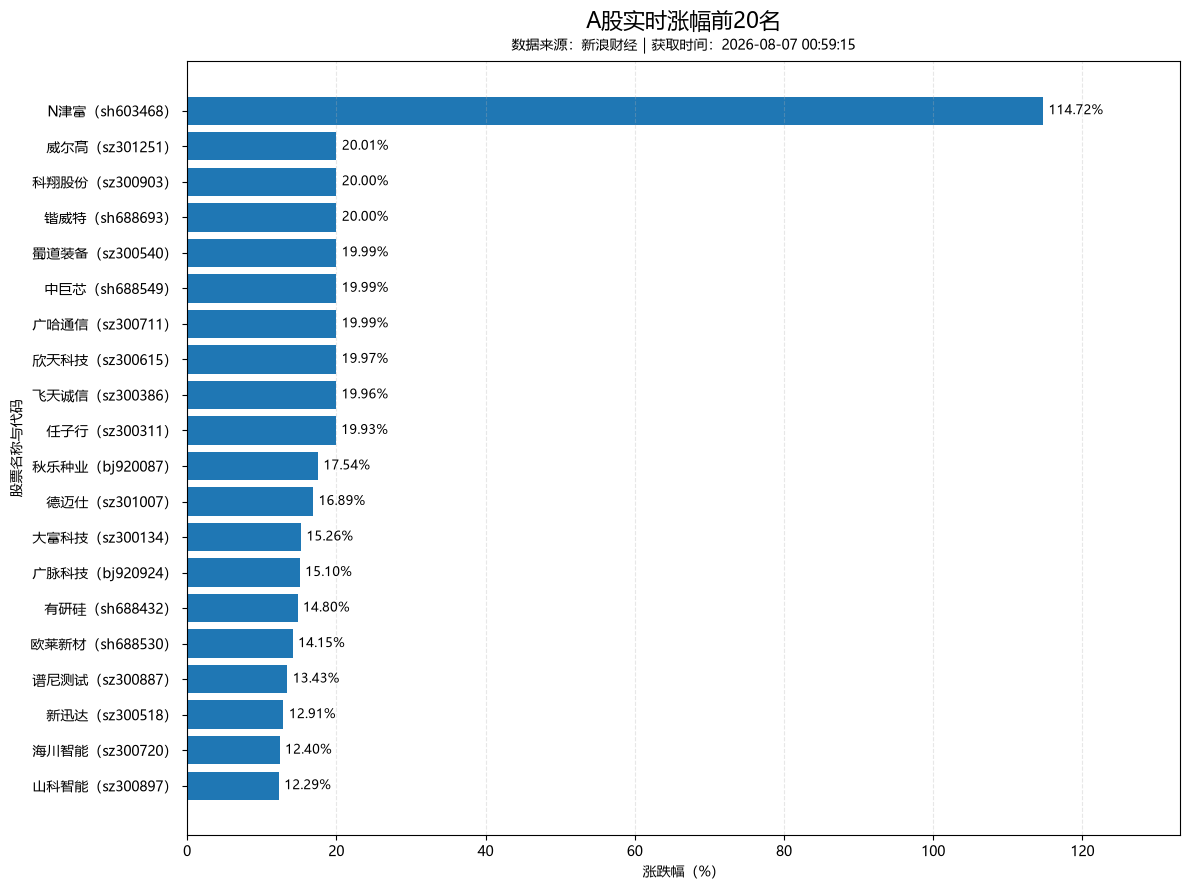

In [11]:
plot_sina = df[["代码", "名称", "涨跌幅"]].copy()

plot_sina["涨跌幅"] = pd.to_numeric(
    plot_sina["涨跌幅"],
    errors="coerce",
)

plot_sina = plot_sina.dropna(
    subset=["名称", "涨跌幅"],
)

# 股票名称同时显示代码
plot_sina["股票"] = (
    plot_sina["名称"].astype(str)
    + "（"
    + plot_sina["代码"].astype(str)
    + "）"
)

# 4. 获取涨幅最高的20只股票
top20_sina = (
    plot_sina
    .nlargest(20, "涨跌幅")
    .sort_values("涨跌幅")
)

# 5. 绘制横向柱状图
fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top20_sina["股票"],
    top20_sina["涨跌幅"],
)

# 6. 在柱形末端显示涨跌幅标签
ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in top20_sina["涨跌幅"]
    ],
    padding=4,
    fontsize=9,
)

# 7. 设置标题和坐标轴
ax.set_title(
    "A股实时涨幅前20名",
    fontsize=16,
    pad=24,
)

ax.text(
    0.5,
    1.01,
    f"数据来源：新浪财经｜获取时间：{pd.Timestamp.now():%Y-%m-%d %H:%M:%S}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_xlabel("涨跌幅（%）")
ax.set_ylabel("股票名称与代码")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

# 为柱形末端标签留出空间
max_value = top20_sina["涨跌幅"].max()
min_value = top20_sina["涨跌幅"].min()

ax.set_xlim(
    left=min(0, min_value),
    right=max_value * 1.16,
)

plt.tight_layout()
plt.show()

In [12]:
# 2. A股实时行情（腾讯）
df = ak.stock_zh_a_spot_tx()

print('A股实时行情:', df.shape)

df.tail(5)

  0%|          | 0/27 [00:00<?, ?it/s]

A股实时行情: (5538, 28)


,code,hsl,lb,ltsz,name,pe_ttm,pn,speed,state,stock_type,...,zdf_w52,zdf_y,zf,zljlr,zllc,zllc_d5,zllr,zllr_d5,zsz,zxj
5533,sz300246,0.00,0.00,40.73,宝莱特,-55.88,4.73,0.00,S,GP-A-CYB,...,99.77,137.78,0.00,0.00,0.00,0.00,0.00,0.00,50.96,19.26
5534,sz300862,0.00,0.00,28.79,蓝盾光电,-36.90,1.79,0.00,S,GP-A-CYB,...,-22.47,-16.90,0.00,0.00,0.00,0.00,0.00,0.00,35.10,19.01
5535,sz300125,0.00,0.00,32.04,*ST聆达,151.06,5.66,0.00,S,GP-A-CYB,...,60.99,16.38,0.00,0.00,0.00,0.00,0.00,0.00,59.13,8.88
5536,sz300333,0.00,0.00,29.69,兆日科技,-139.44,5.29,0.00,S,GP-A-CYB,...,-37.54,-22.87,0.00,0.00,0.00,0.00,0.00,0.00,29.80,8.87
5537,sz000838,0.00,0.00,26.34,*ST发展,-4.29,-12.82,0.00,S,GP-A,...,-16.39,-19.09,0.00,0.00,0.00,0.00,0.00,0.00,27.51,2.50


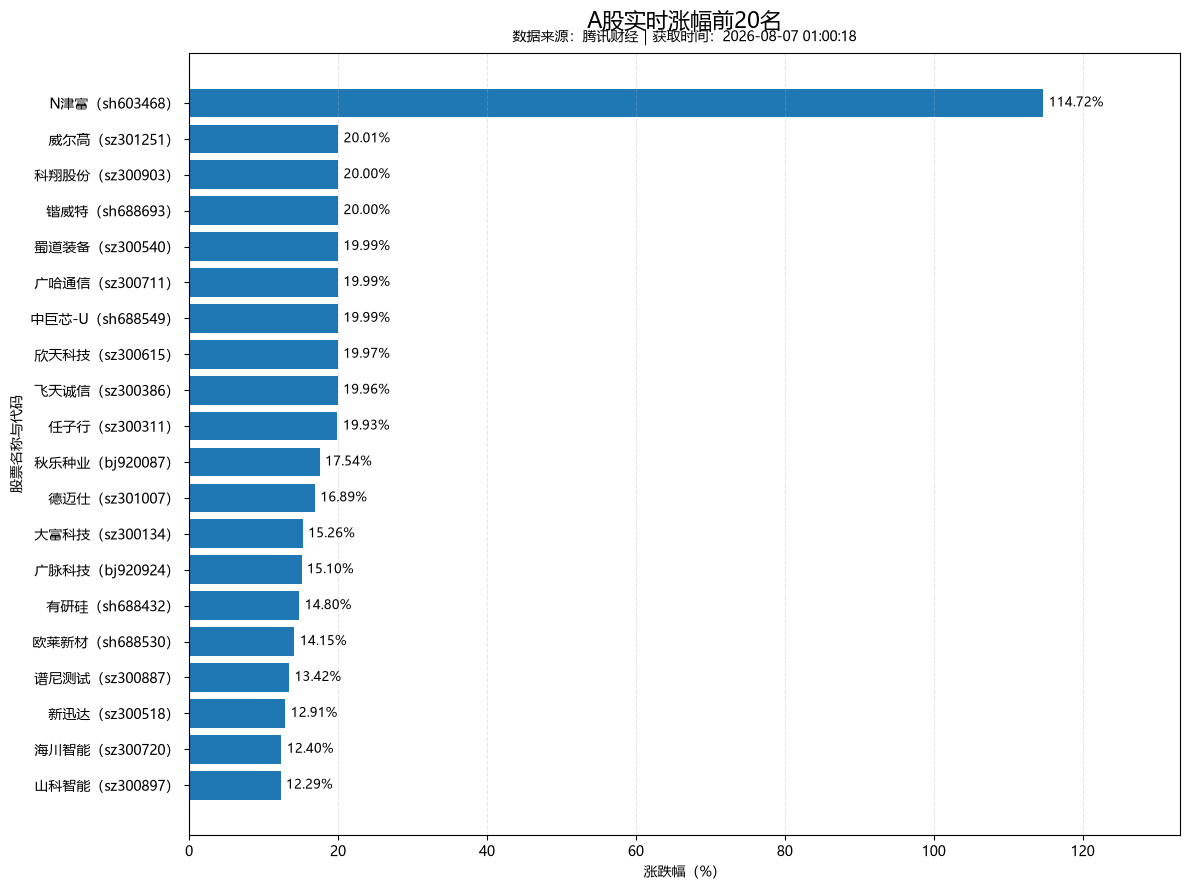

In [13]:
plot_tx = df[["code", "name", "zdf"]].copy()

plot_tx["zdf"] = pd.to_numeric(
    plot_tx["zdf"],
    errors="coerce",
)

plot_tx = plot_tx.dropna(
    subset=["name", "zdf"],
)

# 股票名称同时显示代码
plot_tx["股票"] = (
    plot_tx["name"].astype(str)
    + "（"
    + plot_tx["code"].astype(str)
    + "）"
)

# 4. 取涨幅最高的20只
top20_tx = (
    plot_tx
    .nlargest(20, "zdf")
    .sort_values("zdf")
)

# 5. 绘图
fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top20_tx["股票"],
    top20_tx["zdf"],
)

# 6. 给每根柱子增加数值标签
ax.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in top20_tx["zdf"]],
    padding=4,
    fontsize=9,
)

ax.set_title(
    "A股实时涨幅前20名",
    fontsize=16,
    pad=18,
)

# 副标题：注明数据来源和获取时间
ax.text(
    0.5,
    1.01,
    f"数据来源：腾讯财经｜获取时间：{pd.Timestamp.now():%Y-%m-%d %H:%M:%S}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_xlabel("涨跌幅（%）")
ax.set_ylabel("股票名称与代码")
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

# 为最右侧标签留出空间
max_value = top20_tx["zdf"].max()
ax.set_xlim(
    left=min(0, top20_tx["zdf"].min()),
    right=max_value * 1.16,
)

plt.tight_layout()
plt.show()

#### 科创板

In [14]:
df = ak.stock_zh_kcb_spot()

print('科创板实时行情:', df.shape)

df.tail(5)

科创板实时行情: (612, 19)


,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时点,市盈率,市净率,流通市值,总市值,换手率
607,sh688819,天能股份,22.22,-0.41,-1.812,22.22,22.23,22.63,22.54,22.65,22.12,2734221,60971154,15:34:59,13.549,1.260,2.160006e+06,2.160006e+06,0.28127
608,sh688820,盛合晶微,136.26,4.04,3.056,136.26,136.27,132.22,130.03,141.00,128.65,19014470,2584788987,15:34:59,0.000,17.551,2.538216e+07,2.355971e+06,10.99721
609,sh688825,长鑫科技,51.96,-2.34,-4.309,51.96,51.97,54.30,52.96,53.23,51.13,560574859,29151895973,15:34:59,1732.000,42.524,3.475131e+08,2.339779e+07,12.44881
610,sh688981,中芯国际,124.15,-1.30,-1.036,124.15,124.16,125.45,122.00,126.99,121.88,51888149,6429444648,15:34:59,197.063,7.095,1.062856e+08,2.482457e+07,2.59498
611,sh689009,九号公司,42.60,0.34,0.805,42.59,42.60,42.26,42.22,42.87,41.81,10394790,439783992,15:34:59,1.723,0.423,3.134715e+06,2.395106e+06,1.84885


#### 指数

In [15]:
df = ak.stock_zh_index_spot_sina()

print('A股指数实时行情:', df.shape)

df.head(5)

  0%|          | 0/8 [00:00<?, ?it/s]

A股指数实时行情: (562, 11)


,代码,名称,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低,成交量,成交额
0,sh000001,上证指数,3900.3523,21.923,0.565,3878.4296,3864.2734,3902.0543,3864.2734,588555280,1166818677225
1,sh000002,Ａ股指数,4089.5860,23.017,0.566,4066.5687,4051.7058,4091.3861,4051.7058,588151763,1166259577370
2,sh000003,Ｂ股指数,280.6357,-0.580,-0.206,281.2158,281.0682,281.9996,280.1482,299569,119315863
3,sh000004,工业指数,3704.4947,34.274,0.934,3670.2209,3649.7187,3710.6486,3649.7187,383872014,976823680822
4,sh000005,商业指数,2581.4749,-7.794,-0.301,2589.2686,2588.4319,2590.7430,2565.2157,35865086,36084580128


In [16]:
df = ak.stock_hk_index_spot_sina()

print('港股指数实时行情:', df.shape)

df.head(5)

港股指数实时行情: (38, 9)


,代码,名称,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低
0,CES100,中华港股通精选100指数,5459.543,-93.049,-1.676,5552.593,5484.993,5484.993,5420.788
1,CES120,中华120指数,6586.122,-60.415,-0.909,6646.536,6608.190,6609.556,6566.173
2,CES280,中华280指数,8228.238,-3.644,-0.044,8231.882,8159.431,8269.158,8156.932
3,CES300,中华沪深港300指数,5193.901,-43.447,-0.830,5237.348,5191.663,5203.382,5166.076
4,CESA80,中华A80指数,8129.012,-23.886,-0.293,8152.898,8107.696,8169.594,8077.794


### 历史行情
- A股
- 指数
- 科创板
- 港股
- 美股

#### A股

In [17]:
# 1. A股历史日K线（新浪，symbol需带前缀）
df = ak.stock_zh_a_daily(symbol="sz000002", start_date="20260701", end_date="20260731", adjust="qfq")
print('历史K线:', df.shape)

df.tail()

历史K线: (23, 9)


,date,open,high,low,close,volume,amount,outstanding_share,turnover
18,2026-07-27,3.06,3.14,3.05,3.13,86094393.0,268327130.0,9.716936e+09,0.008860
19,2026-07-28,3.10,3.16,3.10,3.15,91154451.0,286213794.0,9.716936e+09,0.009381
20,2026-07-29,3.15,3.31,3.14,3.28,241362576.0,782087086.0,9.716936e+09,0.024839
21,2026-07-30,3.26,3.40,3.26,3.33,211866620.0,708739129.0,9.716936e+09,0.021804
22,2026-07-31,3.29,3.36,3.28,3.34,125602653.0,418168882.0,9.716936e+09,0.012926


In [18]:
# 2. A股历史日K线（腾讯）
df = ak.stock_zh_a_hist_tx(
    symbol='000002',
    start_date='20260701',
    end_date='20260731',
    adjust='qfq'  # 前复权
)
print('历史K线:', df.shape)

df.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

历史K线: (23, 8)


,date,open,close,high,low,volume,turnover,amount
18,2026-07-27,3.06,3.13,3.14,3.05,860944.0,0.0089,268327100.0
19,2026-07-28,3.10,3.15,3.16,3.10,911545.0,0.0094,286213800.0
20,2026-07-29,3.15,3.28,3.31,3.14,2413626.0,0.0248,782087100.0
21,2026-07-30,3.26,3.33,3.40,3.26,2118666.0,0.0218,708739100.0
22,2026-07-31,3.29,3.34,3.36,3.28,1256027.0,0.0129,418168900.0


findfont: Failed to find font weight semibold, now using 700.


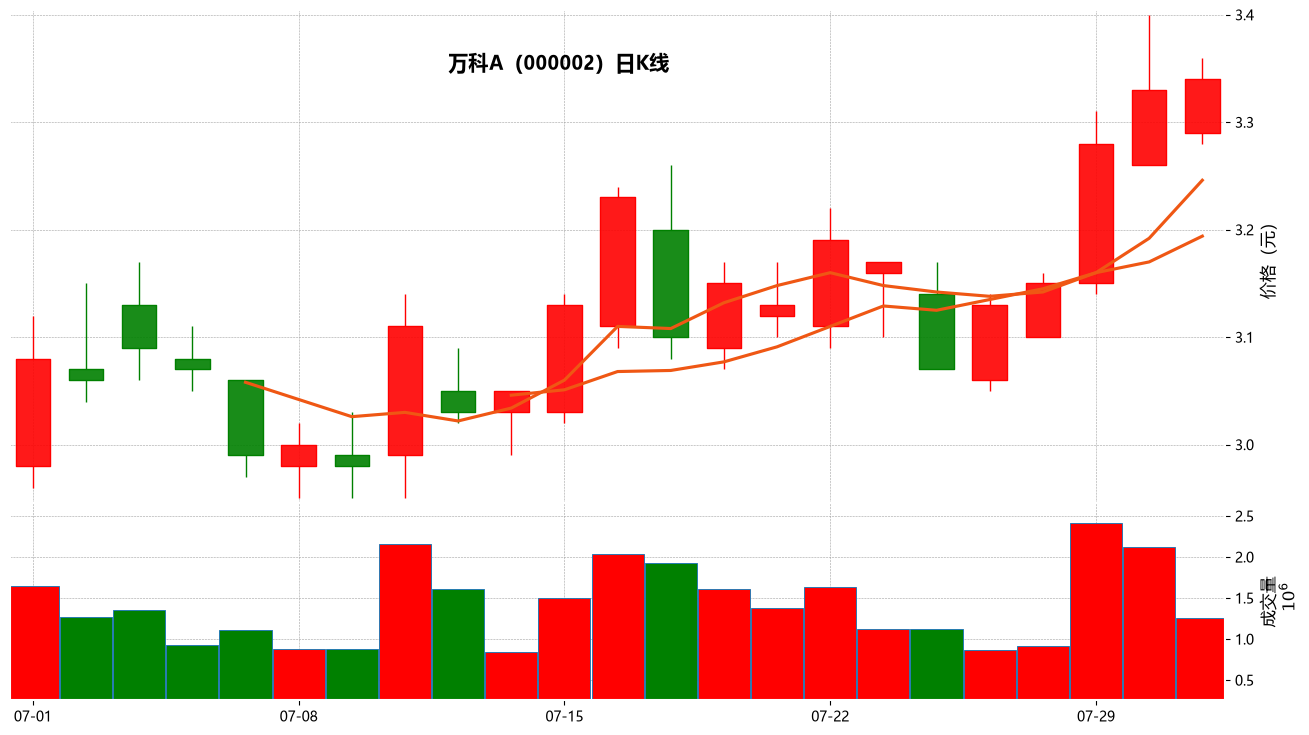

In [19]:
# 1. 复制数据，避免反复执行 Notebook 时修改原始 df
plot_df = df.copy()

# 2. 腾讯接口返回的是英文小写字段
plot_df = plot_df.rename(columns={
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

# 3. 日期必须成为 DatetimeIndex
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.set_index("Date").sort_index()

# 4. 保证 OHLCV 是数值
price_columns = ["Open", "High", "Low", "Close", "Volume"]
plot_df[price_columns] = plot_df[price_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

plot_df = plot_df.dropna(subset=["Open", "High", "Low", "Close"])

# 5. A股配色：红涨绿跌
market_colors = mpf.make_marketcolors(
    up="red",
    down="green",
    edge="inherit",
    wick="inherit",
    volume="inherit",
)

# 6. 创建支持中文的 mplfinance 样式
cn_style = mpf.make_mpf_style(
    base_mpf_style="charles",
    marketcolors=market_colors,
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
        "font.weight": "normal",
        "axes.titleweight": "normal",
        "axes.labelweight": "normal",
    },
)

# 7. 绗制K线
mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    mav=(5, 10),
    title="万科A（000002）日K线",
    ylabel="价格（元）",
    ylabel_lower="成交量",
    style=cn_style,       # 不再写 style="charles"
    figsize=(14, 8),
    datetime_format="%m-%d",
    xrotation=0,
    tight_layout=True,
)

#### 指数

In [20]:
df = ak.stock_zh_index_daily(symbol="sh000001")

print('上证指数日线:', df.shape)

df

上证指数日线: (8698, 6)


,date,open,high,low,close,volume
0,1990-12-19,96.050,99.980,95.790,99.980,126000
1,1990-12-20,104.300,104.390,99.980,104.390,19700
2,1990-12-21,109.070,109.130,103.730,109.130,2800
3,1990-12-24,113.570,114.550,109.130,114.550,3200
4,1990-12-25,120.090,120.250,114.550,120.250,1500
...,...,...,...,...,...,...
8693,2026-07-31,3833.536,3847.093,3822.374,3832.262,59752942700
8694,2026-08-03,3812.613,3827.636,3797.643,3809.663,52451696000
8695,2026-08-04,3816.370,3831.940,3799.524,3822.285,54032492200
8696,2026-08-05,3815.122,3884.397,3815.122,3878.430,59215512400


### 分时与逐笔

In [21]:
df = ak.stock_zh_a_minute(symbol='sz000002')

df = df.set_index('day')

print('A股分钟行情-新浪：', df.shape)

df.tail()

A股分钟行情-新浪： (1970, 6)


,open,high,low,close,volume,amount
day,,,,,,
2026-08-06 14:54:00,3.260,3.260,3.250,3.260,518303,1685357.7500
2026-08-06 14:55:00,3.260,3.260,3.250,3.260,98400,320356.0000
2026-08-06 14:56:00,3.260,3.260,3.250,3.260,663700,2162744.0000
2026-08-06 14:57:00,3.260,3.260,3.250,3.260,360200,1173459.0000
2026-08-06 15:00:00,3.260,3.260,3.260,3.260,896700,2923242.0013


In [22]:
df = ak.stock_zh_a_tick_tx_js(symbol='sz000002')

df = df.set_index('成交时间')

print('A股逐笔成交-腾讯：', df.shape)

df.tail()

C:\Users\theTruth\Documents\projects\vibe-working\trading-topic\labs\.venv\Lib\site-packages\akshare\stock\stock_zh_a_tick_tx.py:27: UserWarning: 正在下载数据，请稍等
  warnings.warn("正在下载数据，请稍等")


A股逐笔成交-腾讯： (3994, 5)


,成交价格,价格变动,成交量,成交金额,性质
成交时间,,,,,
15:00:00,3.26,0.0,8967,2923242,买盘
15:05:00,3.26,0.0,23,7498,中性盘
15:08:15,3.26,0.0,1,326,买盘
15:08:45,3.26,0.0,1,326,买盘
15:12:00,3.26,0.0,5,1630,买盘


In [23]:
# 限量: 单次返回指定交易日的分时数据；只能获取近期的数据，此处仅返回大单数据（成交量大于等于: 400手）
df = ak.stock_intraday_sina(symbol='sz000002', date="20260721")

df = df.set_index('ticktime')

print('日内分时-新浪：', df.shape)

df.tail()

  0%|          | 0/17 [00:00<?, ?it/s]

日内分时-新浪： (995, 6)


,symbol,name,price,volume,prev_price,kind
ticktime,,,,,,
14:56:51,sz000002,万 科Ａ,3.13,25200,3.13,U
14:56:54,sz000002,万 科Ａ,3.13,45000,3.13,U
14:56:57,sz000002,万 科Ａ,3.13,23700,3.13,U
14:57:00,sz000002,万 科Ａ,3.13,20900,3.13,U
15:00:00,sz000002,万 科Ａ,3.13,1206800,3.13,E


### 估值指标

In [24]:
# 1. A股估值指标（东方财富）
df = ak.stock_value_em(symbol='000002')

df = df.set_index('数据日期')

print('估值指标:', df.shape)

df.tail()

估值指标: (2085, 12)


,当日收盘价,当日涨跌幅,总市值,流通市值,总股本,流通股本,PE(TTM),PE(静),市净率,PEG值,市现率,市销率
数据日期,,,,,,,,,,,,
2026-07-31,3.34,0.300300,3.984857e+10,3.245457e+10,11930709471,9716935865,-0.451478,-0.449979,0.360506,0.003844,15.088334,0.177605
2026-08-03,3.36,0.598802,4.008718e+10,3.264890e+10,11930709471,9716935865,-0.454182,-0.452674,0.362664,0.003867,15.178683,0.178669
2026-08-04,3.26,-2.976190,3.889411e+10,3.167721e+10,11930709471,9716935865,-0.440664,-0.439201,0.351871,0.003752,14.726937,0.173351
2026-08-05,3.28,0.613497,3.913273e+10,3.187155e+10,11930709471,9716935865,-0.443368,-0.441896,0.354030,0.003775,14.817286,0.174415
2026-08-06,3.26,-0.609756,3.889411e+10,3.167721e+10,11930709471,9716935865,-0.440664,-0.439201,0.351871,0.003752,14.726937,0.173351


### 停复牌状态

In [25]:
df = ak.stock_tfp_em(date="20260801")

print('停复牌信息-东方财富:', df.shape)

df

停复牌信息-东方财富: (10, 9)


,序号,代码,名称,停牌时间,停牌截止时间,停牌期限,停牌原因,所属市场,预计复牌时间
0,0,300125,*ST聆达,2026-08-06,2026-08-06,停牌一天,刊登重要公告,深交所创业板,2026-08-07
1,1,002214,*ST大立,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所主板,2026-08-05
2,2,300311,ST任子行,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所创业板,2026-08-05
3,3,300246,宝莱特,2026-08-03,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
4,4,600530,ST交昂,2026-08-03,2026-08-03,停牌一天,刊登重要公告,上交所风险警示板,2026-08-04
5,5,000838,*ST发展,2026-08-03,NaT,连续停牌,刊登重要公告,深交所风险警示板,NaT
6,6,603221,爱丽家居,2026-08-03,2026-08-05,连续停牌,交易异常波动,上交所主板,2026-08-06
7,7,300333,兆日科技,2026-07-30,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
8,8,300862,蓝盾光电,2026-07-27,2026-08-07,连续停牌,刊登重要公告,深交所创业板,2026-08-10
9,9,200706,瓦轴B,2026-03-02,NaT,连续停牌,刊登重要公告,深交所主板,NaT


---
## 3. `fundamentals`：公司与财务基本面

回答“这家公司经营得怎么样”。

覆盖公司所有经营数据，包括：公司资料；A股、港股、美股财务报表；财务指标；主营业务；股东持仓；盈利预测；商誉；ESG。

**本教程收录的当前可用接口：47 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称                  | 接口函数                                          | 数据源  |
| -: | ----- | --------------------- | --------------------------------------------- | ---- |
|  1 | 公司资料  | 公司概况-巨潮               | `stock_profile_cninfo`                        | 巨潮资讯 |
|  2 | 公司资料  | 港股公司资料-东方财富           | `stock_hk_company_profile_em`                 | 东方财富 |
|  3 | 公司资料  | 主营构成-东方财富             | `stock_zygc_em`                               | 东方财富 |
|  4 | 公司资料  | 主营介绍-同花顺              | `stock_zyjs_ths`                              | 同花顺  |
|  5 | 财务报表  | 三大财务报表-新浪             | `stock_financial_report_sina`                 | 新浪财经 |
|  6 | 财务报表  | 港股三大财务报表-东方财富         | `stock_financial_hk_report_em`                | 东方财富 |
|  7 | 财务报表  | 美股三大财务报表-东方财富         | `stock_financial_us_report_em`                | 东方财富 |
|  8 | 财务报表  | 资产负债表-报告期-东方财富        | `stock_balance_sheet_by_report_em`            | 东方财富 |
|  9 | 财务报表  | 资产负债表-年度-东方财富         | `stock_balance_sheet_by_yearly_em`            | 东方财富 |
| 10 | 财务报表  | 已退市-资产负债表-报告期-东方财富    | `stock_balance_sheet_by_report_delisted_em`   | 东方财富 |
| 11 | 财务报表  | 资产负债表-同花顺             | `stock_financial_debt_new_ths`                | 同花顺  |
| 12 | 财务报表  | 资产负债表（旧接口）-同花顺        | `stock_financial_debt_ths`                    | 同花顺  |
| 13 | 财务报表  | 利润表-报告期-东方财富          | `stock_profit_sheet_by_report_em`             | 东方财富 |
| 14 | 财务报表  | 利润表-单季度-东方财富          | `stock_profit_sheet_by_quarterly_em`          | 东方财富 |
| 15 | 财务报表  | 利润表-年度-东方财富           | `stock_profit_sheet_by_yearly_em`             | 东方财富 |
| 16 | 财务报表  | 已退市-利润表-报告期-东方财富      | `stock_profit_sheet_by_report_delisted_em`    | 东方财富 |
| 17 | 财务报表  | 利润表-同花顺               | `stock_financial_benefit_new_ths`             | 同花顺  |
| 18 | 财务报表  | 利润表（旧接口）-同花顺          | `stock_financial_benefit_ths`                 | 同花顺  |
| 19 | 财务报表  | 现金流量表-单季度-东方财富        | `stock_cash_flow_sheet_by_quarterly_em`       | 东方财富 |
| 20 | 财务报表  | 现金流量表-报告期-东方财富        | `stock_cash_flow_sheet_by_report_em`          | 东方财富 |
| 21 | 财务报表  | 现金流量表-年度-东方财富         | `stock_cash_flow_sheet_by_yearly_em`          | 东方财富 |
| 22 | 财务报表  | 已退市-现金流量表-报告期-东方财富    | `stock_cash_flow_sheet_by_report_delisted_em` | 东方财富 |
| 23 | 财务报表  | 现金流量表-同花顺             | `stock_financial_cash_new_ths`                | 同花顺  |
| 24 | 财务报表  | 现金流量表（旧接口）-同花顺        | `stock_financial_cash_ths`                    | 同花顺  |
| 25 | 财务指标  | 关键财务指标-新浪             | `stock_financial_abstract`                    | 新浪财经 |
| 26 | 财务指标  | 财务分析指标-新浪             | `stock_financial_analysis_indicator`          | 新浪财经 |
| 27 | 财务指标  | A股主要财务指标-东方财富         | `stock_financial_analysis_indicator_em`       | 东方财富 |
| 28 | 财务指标  | 港股主要财务指标-东方财富         | `stock_financial_hk_analysis_indicator_em`    | 东方财富 |
| 29 | 财务指标  | 美股主要财务指标-东方财富         | `stock_financial_us_analysis_indicator_em`    | 东方财富 |
| 30 | 财务指标  | 港股最新财务指标-东方财富         | `stock_hk_financial_indicator_em`             | 东方财富 |
| 31 | 财务指标  | 重要财务指标-同花顺            | `stock_financial_abstract_new_ths`            | 同花顺  |
| 32 | 财务指标  | 重要财务指标（旧接口）-同花顺       | `stock_financial_abstract_ths`                | 同花顺  |
| 33 | 财务指标  | A股商誉市场概况-东方财富         | `stock_sy_profile_em`                         | 东方财富 |
| 34 | 股东持仓  | 流通股东-新浪               | `stock_circulate_stock_holder`                | 新浪财经 |
| 35 | 股东持仓  | 基金持股-新浪               | `stock_fund_stock_holder`                     | 新浪财经 |
| 36 | 股东持仓  | 主要股东-新浪               | `stock_main_stock_holder`                     | 新浪财经 |
| 37 | 股东持仓  | 股东分析-十大流通股东-东方财富      | `stock_gdfx_free_holding_teamwork_em`         | 东方财富 |
| 38 | 股东持仓  | 股东分析-股东持股分析-十大股东-东方财富 | `stock_gdfx_holding_analyse_em`               | 东方财富 |
| 39 | 股东持仓  | 股东分析-股东持股明细-十大股东-东方财富 | `stock_gdfx_holding_detail_em`                | 东方财富 |
| 40 | 股东持仓  | 股东分析-股东协同-十大股东-东方财富   | `stock_gdfx_holding_teamwork_em`              | 东方财富 |
| 41 | 股东持仓  | 股东户数-东方财富             | `stock_zh_a_gdhs`                             | 东方财富 |
| 42 | 股东持仓  | 股东户数详情-东方财富           | `stock_zh_a_gdhs_detail_em`                   | 东方财富 |
| 43 | 盈利预测  | 盈利预测-东方财富             | `stock_profit_forecast_em`                    | 东方财富 |
| 44 | 盈利预测  | 盈利预测-同花顺              | `stock_profit_forecast_ths`                   | 同花顺  |
| 45 | 盈利预测  | 港股盈利预测-经济通            | `stock_hk_profit_forecast_et`                 | 未识别  |
| 46 | ESG评价 | ESG评级-MSCI-新浪         | `stock_esg_msci_sina`                         | 新浪财经 |
| 47 | ESG评价 | ESG评级-路孚特-新浪          | `stock_esg_rft_sina`                          | 新浪财经 |


### 公司概况、主营业务

In [26]:
# 1. 个股公司概况-巨潮资讯
df = ak.stock_profile_cninfo(symbol="000002")

print('工商概况:', df.shape)

df.iloc[0]

工商概况: (1, 26)


公司名称                                           万科企业股份有限公司
英文名称                                China Vanke Co., Ltd.
曾用简称                                                 None
A股代码                                               000002
A股简称                                                万  科Ａ
B股代码                                                 None
B股简称                                                 None
H股代码                                                02202
H股简称                                                 万科企业
入选指数    ESG 300,国证Ａ指,沪深300,巨潮中盘,深成指R,深市精选,深证100,深证100R...
所属市场                                                深交所主板
所属行业                                                 房地产业
法人代表                                                  徐恩利
注册资金                                         1193070.9471
成立日期                                           1984-05-30
上市日期                                           1991-01-29
官方网站                                        www.vanke.com
电子邮箱          

In [27]:
df = ak.stock_zyjs_ths(symbol="000002")

print('主营业务:', df.shape)

df

主营业务: (1, 5)


,股票代码,主营业务,产品类型,产品名称,经营范围
0,000002,房地产开发和物业服务。,商品住宅,商品住宅,兴办实业(具体项目另行申报)；国内商业；物资供销业(不含专营、专控、专卖商品)；进出口业务(...


In [28]:
df = ak.stock_zygc_em(symbol="sz000002")

print('主营构成:', df.shape)

df.head()

主营构成: (200, 11)


,股票代码,报告日期,分类类型,主营构成,主营收入,收入比例,主营成本,成本比例,主营利润,利润比例,毛利率
0,000002,2025-12-31,按行业分类,房地产开发及相关资产经营业务,1.906512e+11,0.816728,1.741788e+11,0.824136,1.647234e+10,0.745845,0.086400
1,000002,2025-12-31,按行业分类,物业服务,3.552451e+10,0.152183,3.113891e+10,0.147335,4.385601e+09,0.198574,0.123453
2,000002,2025-12-31,按行业分类,其他(补充),7.257101e+09,0.031089,6.029567e+09,0.028529,1.227535e+09,0.055581,0.169149
3,000002,2025-12-31,按地区分类,上海区域,6.288068e+10,0.269374,NaN,NaN,NaN,NaN,NaN
4,000002,2025-12-31,按地区分类,其他主营业务,4.801407e+10,0.205687,2.053177e+11,0.971471,2.085794e+10,0.944419,NaN


### 三大财务报表

In [29]:
# 1. 单次获取指定报表的所有年份数据的历史数据
# symbol="现金流量表"; choice of {"资产负债表", "利润表", "现金流量表"}

df = ak.stock_financial_report_sina(stock='sz000002', symbol="资产负债表")

print('关键指标:', df.shape)

print(df.columns)

df.head(5)

关键指标: (115, 147)
Index(['报告日', '流动资产', '货币资金', '结算备付金', '拆出资金', '交易性金融资产', '买入返售金融资产', '衍生金融资产',
       '应收票据及应收账款', '应收票据',
       ...
       '归属于母公司股东权益合计', '少数股东权益', '所有者权益(或股东权益)合计', '负债和所有者权益(或股东权益)总计', '数据源',
       '是否审计', '公告日期', '币种', '类型', '更新日期'],
      dtype='str', length=147)


,报告日,流动资产,货币资金,结算备付金,拆出资金,交易性金融资产,买入返售金融资产,衍生金融资产,应收票据及应收账款,应收票据,...,归属于母公司股东权益合计,少数股东权益,所有者权益(或股东权益)合计,负债和所有者权益(或股东权益)总计,数据源,是否审计,公告日期,币种,类型,更新日期
0,20260331,NaN,60492624678.93,NaN,NaN,67090770.98,NaN,NaN,10648362166.18,6281646.51,...,110535199285.199997,117526785408.419998,228061984693.619995,997406724022.049927,定期报告,未审计,20260430,CNY,合并期末,2026-04-29T20:24:04
1,20251231,NaN,67240949734.900002,NaN,NaN,68016700.87,NaN,NaN,9521445910.26,2370899.21,...,116905224808.460007,118954833228.229996,235860058036.690002,1020622831532.859985,定期报告,是,20260430,CNY,合并期末,2026-03-31T20:06:13
2,20250930,NaN,65677132971.18,NaN,NaN,16987125.05,NaN,NaN,9596955519.809999,8551631.82,...,175755829577.720001,125274243001.460007,301030072579.180054,1136594565755.290039,定期报告,未审计,20251031,CNY,合并期末,2025-10-30T20:08:10
3,20250630,NaN,74002263778.729996,NaN,NaN,13864659.16,NaN,NaN,9340119833.059999,27960933.51,...,191440815716.190002,129719727244.869995,321160542961.059998,1194148874774.550049,定期报告,未审计,20250823,CNY,合并期末,2025-08-22T20:08:05
4,20250331,NaN,75501915435.039993,NaN,NaN,16896775.47,NaN,NaN,9215986830.559999,30620368.21,...,196728878701.040009,133245534134.210007,329974412835.25,1244039386215.600098,定期报告,未审计,20250430,CNY,合并期末,2025-04-29T20:42:08


#### 资产负债表

In [30]:
# 1. 同花顺资产负债表
df = ak.stock_financial_debt_new_ths(symbol="000002", indicator="按年度")

print('资产负债表:', df.shape)

print(df['report_name'].unique())
print(df['quarter_name'].unique())
print(df['metric_name'].unique())

df.head(5)

资产负债表: (4165, 10)
<StringArray>
['2025年报', '2024年报', '2023年报', '2022年报', '2021年报', '2020年报', '2019年报',
 '2018年报', '2017年报', '2016年报', '2015年报', '2014年报', '2013年报', '2012年报',
 '2011年报', '2010年报', '2009年报', '2008年报', '2007年报', '2006年报', '2005年报',
 '2004年报', '2003年报', '2002年报', '2001年报', '2000年报', '1999年报', '1998年报',
 '1997年报', '1996年报', '1995年报', '1994年报', '1993年报', '1992年报', '1991年报']
Length: 35, dtype: str
<StringArray>
['2025四季度', '2024四季度', '2023四季度', '2022四季度', '2021四季度', '2020四季度', '2019四季度',
 '2018四季度', '2017四季度', '2016四季度', '2015四季度', '2014四季度', '2013四季度', '2012四季度',
 '2011四季度', '2010四季度', '2009四季度', '2008四季度', '2007四季度', '2006四季度', '2005四季度',
 '2004四季度', '2003四季度', '2002四季度', '2001四季度', '2000四季度', '1999四季度', '1998四季度',
 '1997四季度', '1996四季度', '1995四季度', '1994四季度', '1993四季度', '1992四季度', '1991四季度']
Length: 35, dtype: str
<StringArray>
[                          'treasury_stock',
             'productive_biological_assets',
                        'deferred_tax_debt',
              

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,treasury_stock,,,,,
1,2025-12-31,2025年报,2025-4,2025四季度,productive_biological_assets,216117733.5300,,-0.14878916,,
2,2025-12-31,2025年报,2025-4,2025四季度,deferred_tax_debt,4697757860.4900,,-0.12170587,,
3,2025-12-31,2025年报,2025-4,2025四季度,other_payable_total,133735785207.2500,,-0.12199084,,
4,2025-12-31,2025年报,2025-4,2025四季度,equity,11930709471.0000,,0.00000000,,


#### 利润表

In [31]:
# 1. 同花顺利润表
df = ak.stock_financial_benefit_new_ths(symbol="000002", indicator="按年度")

print('利润表:', df.shape)

print(df['metric_name'].unique())

df.head(5)

利润表: (1734, 10)
<StringArray>
[                            'profit_total',
                          'exchange_income',
                   'non_operating_expenses',
                          'premiums_earned',
                'net_exposure_hedge_income',
                                  'payouts',
            'minority_comprehensive_income',
                   'operating_income_total',
                               'manage_fee',
                    'asset_disposal_income',
                    'continuing_net_profit',
                            'invest_income',
                             'other_income',
 'financial_assets_measured_amortized_cost',
                                'basic_eps',
        'parent_other_comprehensive_income',
                          'surrender_money',
                  'dividend_payment_policy',
             'operating_cost_total_special',
                         'operating_profit',
                  'associate_invest_income',
             'charges_com

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,profit_total,-73923814314.9700,,-0.56662862,,
1,2025-12-31,2025年报,2025-4,2025四季度,exchange_income,,,,,
2,2025-12-31,2025年报,2025-4,2025四季度,non_operating_expenses,3688680011.6800,,0.48816955,,
3,2025-12-31,2025年报,2025-4,2025四季度,premiums_earned,,,,,
4,2025-12-31,2025年报,2025-4,2025四季度,net_exposure_hedge_income,,,,,


#### 现金流量表

In [32]:
# 1. 同花顺现金流量
df = ak.stock_financial_cash_new_ths(symbol="000002", indicator="按年度")

print('利润表:', df.shape)

print(df['metric_name'].unique())

df.head(5)

利润表: (2520, 10)
<StringArray>
[                 'financing_cash_inflow_special',
                      'invest_cash_outflow_total',
               'pay_other_related_financing_cash',
                                  'pay_debt_cash',
                   'financing_cash_outflow_total',
                'subsidiary_pay_holder_dividends',
 'dispose_fixed_intangible_long_term_assets_loss',
                'deposits_and_funds_net_addition',
          'cash_equivalents_net_addition_special',
                  'repurchase_funds_net_addition',
           'pay_interest_fee_and_commission_cash',
                           'received_invest_cash',
                 'received_origin_insurance_cash',
                     'receive_issuance_bond_cash',
                      'borrow_other_net_addition',
             'pay_origin_insurance_contract_cash',
 'disposal_financial_assets_measure_net_addition',
                    'financing_cash_inflow_total',
                                'investment_loss',
 

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,financing_cash_inflow_special,,,,,
1,2025-12-31,2025年报,2025-4,2025四季度,invest_cash_outflow_total,5843412573.1500,622438114.2600,-0.34188911,-0.76413723,-0.73816726
2,2025-12-31,2025年报,2025-4,2025四季度,pay_other_related_financing_cash,2218317875.6000,499882276.6800,-0.16140627,-0.13482872,-0.40279521
3,2025-12-31,2025年报,2025-4,2025四季度,pay_debt_cash,56603589457.0300,6821945387.4300,-0.28368289,-0.49779401,-0.29116108
4,2025-12-31,2025年报,2025-4,2025四季度,financing_cash_outflow_total,74959012705.6300,9727562112.7600,-0.29260229,-0.48179937,-0.30595283


### 财务指标

In [33]:
# 单次获取指定 symbol 和 start_year 的所有财务指标历史数据

df = ak.stock_financial_analysis_indicator(symbol="000002", start_year="2020")

print('财务指标:', df.shape)
print('财务指标:', df.columns)

df.head(5)

  0%|          | 0/7 [00:00<?, ?it/s]

财务指标: (25, 86)
财务指标: Index(['日期', '摊薄每股收益(元)', '加权每股收益(元)', '每股收益_调整后(元)', '扣除非经常性损益后的每股收益(元)',
       '每股净资产_调整前(元)', '每股净资产_调整后(元)', '每股经营性现金流(元)', '每股资本公积金(元)',
       '每股未分配利润(元)', '调整后的每股净资产(元)', '总资产利润率(%)', '主营业务利润率(%)', '总资产净利润率(%)',
       '成本费用利润率(%)', '营业利润率(%)', '主营业务成本率(%)', '销售净利率(%)', '股本报酬率(%)',
       '净资产报酬率(%)', '资产报酬率(%)', '销售毛利率(%)', '三项费用比重', '非主营比重', '主营利润比重',
       '股息发放率(%)', '投资收益率(%)', '主营业务利润(元)', '净资产收益率(%)', '加权净资产收益率(%)',
       '扣除非经常性损益后的净利润(元)', '主营业务收入增长率(%)', '净利润增长率(%)', '净资产增长率(%)',
       '总资产增长率(%)', '应收账款周转率(次)', '应收账款周转天数(天)', '存货周转天数(天)', '存货周转率(次)',
       '固定资产周转率(次)', '总资产周转率(次)', '总资产周转天数(天)', '流动资产周转率(次)', '流动资产周转天数(天)',
       '股东权益周转率(次)', '流动比率', '速动比率', '现金比率(%)', '利息支付倍数', '长期债务与营运资金比率(%)',
       '股东权益比率(%)', '长期负债比率(%)', '股东权益与固定资产比率(%)', '负债与所有者权益比率(%)',
       '长期资产与长期资金比率(%)', '资本化比率(%)', '固定资产净值率(%)', '资本固定化比率(%)', '产权比率(%)',
       '清算价值比率(%)', '固定资产比重(%)', '资产负债率(%)', '总资产(元)', '经营现金净流量对销售收入比率(%)',
       '资产的经营现金流量回报率(%)', 

,日期,摊薄每股收益(元),加权每股收益(元),每股收益_调整后(元),扣除非经常性损益后的每股收益(元),每股净资产_调整前(元),每股净资产_调整后(元),每股经营性现金流(元),每股资本公积金(元),每股未分配利润(元),...,2-3年以内应收帐款(元),3年以内应收帐款(元),1年以内预付货款(元),1-2年以内预付货款(元),2-3年以内预付货款(元),3年以内预付货款(元),1年以内其它应收款(元),1-2年以内其它应收款(元),2-3年以内其它应收款(元),3年以内其它应收款(元)
0,2020-03-31,0.2150,0.1110,0.1110,NaN,24.2530,16.6928,-0.2614,1.0918,8.5472,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-06-30,1.6035,1.1100,1.1100,1.07,25.0700,16.8400,1.9458,1.6572,8.2674,...,NaN,NaN,NaN,1.669637e+10,2.301901e+10,NaN,NaN,5.929571e+10,3.605168e+10,NaN
2,2020-09-30,2.5884,1.7410,1.7410,NaN,26.0500,17.4453,2.8733,1.6145,8.9005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-31,5.1041,3.6200,3.6200,3.51,30.1130,19.3200,4.5782,1.5971,8.4713,...,NaN,NaN,NaN,2.141890e+09,3.744288e+09,NaN,NaN,5.093053e+10,3.237831e+10,NaN
4,2021-03-31,0.2158,0.1112,0.1112,NaN,30.5939,19.4279,1.4529,1.5877,8.5825,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 股东持仓

In [34]:
# 1. 流通股东（新浪）
df = ak.stock_circulate_stock_holder(symbol='sz000002')

print('流通股东:', df.shape)

df.head(5)

  0%|          | 0/90 [00:00<?, ?it/s]

流通股东: (895, 7)


,截止日期,公告日期,编号,股东名称,持股数量,占流通股比例,股本性质
0,2026-03-31,2026-04-30,1,深铁集团,3242810791,27.197,国有股
1,2026-03-31,2026-04-30,2,HKSCC NOMINEES LIMITED,2206363864,18.504,境外法人股
2,2026-03-31,2026-04-30,3,中央汇金资产管理有限责任公司,185478200,1.556,国有股
3,2026-03-31,2026-04-30,4,香港中央结算有限公司,147049855,1.233,境外法人股
4,2026-03-31,2026-04-30,5,中国工商银行股份有限公司-南方中证全指房地产交易型开放式指数证券投资基金,81997589,0.688,境内法人股


In [35]:
# 2. 基金持股（新浪）
df = ak.stock_fund_stock_holder(symbol='sz000002')

print('流通股东:', df.shape)

df.head(5)

  0%|          | 0/7 [00:00<?, ?it/s]

流通股东: (993, 7)


,基金名称,基金代码,持仓数量,占流通股比例,持股市值,占净值比例,截止日期
0,招商沪深300地产等权重指数C,013273,103786318,0.8699,307207000.0,34.14,2026-06-30
1,南方中证全指房地产ETF,512200,53557589,0.4489,158530000.0,5.03,2026-06-30
2,华宝中证800地产ETF,159707,25711781,0.2155,76106900.0,15.65,2026-06-30
3,房地产ETF,159768,17581479,0.1474,52041200.0,15.59,2026-06-30
4,鹏华中证800地产指数(LOF)A,160628,8540887,0.0716,25281000.0,15.01,2026-06-30


In [36]:
# 3. 主要股东-新浪
df = ak.stock_main_stock_holder(stock='000002')

print('主要股东:', df.shape)

df.head(5)

主要股东: (1118, 10)


,编号,股东名称,持股数量,持股比例,股本性质,截至日期,公告日期,股东说明,股东总数,平均持股数
0,1,深圳市地铁集团有限公司,3.242811e+09,27.18,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
1,2,HKSCC NOMINEES LIMITED,2.206364e+09,18.49,流通H股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
2,3,中央汇金资产管理有限责任公司,1.854782e+08,1.55,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
3,4,香港中央结算有限公司,NaN,NaN,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
4,5,中国工商银行股份有限公司-南方中证全指房地产交易型开放式指数证券投资基金,NaN,NaN,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0


### 盈利预测

In [37]:
# 盈利预测-同花顺
df = ak.stock_profit_forecast_ths(symbol='000002')

print('盈利预测-同花顺:', df.shape)

df.head(5)

盈利预测-同花顺: (3, 6)


,年度,预测机构数,最小值,均值,最大值,行业平均数
0,2026,5,-3.43,-2.24,-1.44,0.21
1,2027,5,-2.34,-1.50,-1.00,0.37
2,2028,4,-1.51,-0.90,0.02,0.46


In [38]:
# 盈利预测-东方财富
df = ak.stock_profit_forecast_em()

print('盈利预测-同花顺:', df.shape)

df.head(5)

  0%|          | 0/6 [00:00<?, ?it/s]

盈利预测-同花顺: (2814, 13)


,序号,代码,名称,研报数,机构投资评级(近六个月)-买入,机构投资评级(近六个月)-增持,机构投资评级(近六个月)-中性,机构投资评级(近六个月)-减持,机构投资评级(近六个月)-卖出,2025预测每股收益,2026预测每股收益,2027预测每股收益,2028预测每股收益
0,1,600519,贵州茅台,44,37.0,7.0,0.0,0.0,0.0,65.851755,68.731400,72.483356,76.040700
1,2,605499,东鹏饮料,41,27.0,14.0,0.0,0.0,0.0,6.013712,7.938878,9.192100,10.353135
2,3,603345,安井食品,39,31.0,8.0,0.0,0.0,0.0,4.078255,5.334897,6.049949,6.744486
3,4,300750,宁德时代,38,31.0,7.0,0.0,0.0,0.0,15.605504,20.787811,25.887054,31.069611
4,5,600600,青岛啤酒,35,24.0,11.0,0.0,0.0,0.0,3.363229,3.534571,3.730286,3.925588


### ESG评级

In [39]:
# ESG评级-MSCI-新浪
df = ak.stock_esg_rft_sina()

print('ESG评级-路孚特-新浪:', df.shape)

df.head(5)

ESG评级-路孚特-新浪: (100, 13)


,股票代码,ESG评分,ESG评分日期,环境总评,环境总评日期,社会责任总评,社会责任总评日期,治理总评,治理总评日期,争议总评,争议总评日期,行业,交易所
0,AMED,55.9(B-),2026-08-01,20.4(D+),2026-08-01,60.0(B),2026-08-01,68.8(B+),2026-08-01,81.4(A-),2026-07-25,医疗-护理服务,纳斯达克
1,600460.SH,35.7(C),2026-08-01,40.5(C),2026-08-01,40.1(C),2026-08-01,22.5(D+),2026-08-01,100.0(A+),2026-05-23,半导体,上交所
2,UVSP,46.8(C+),2026-08-01,16.9(D+),2026-08-01,54.0(B-),2026-08-01,48.8(C+),2026-08-01,100.0(A+),2026-04-11,区域银行,纳斯达克
3,EAR,13.8(D),2026-08-01,4.0(D-),2026-08-01,17.1(D+),2026-08-01,14.2(D),2026-08-01,100.0(A+),2023-08-26,专业医疗,纳斯达克
4,SUZ,75.9(A-),2026-08-01,58.7(B),2026-08-01,91.7(A+),2026-08-01,88.6(A),2026-08-01,91.7(A+),2026-06-20,纸浆-纸,纽交所


---
## 4. `corporate_actions`：公司行为与股本事件

回答“持有人的权益发生了什么”。涵盖发行、分红、回购、解禁、质押和股本变化。

| 行为   | 钱从哪里来/到哪里去    | 股本变化 | 对老股东的核心影响         |
| ---- | ------------- | ---: | ----------------- |
| 增发   | 新投资者向公司投入资金   |   增加 | 可能被稀释，公司获得融资      |
| 配股   | 原股东按持股比例向公司缴款 |   增加 | 不参与通常会被稀释         |
| 股份回购 | 公司拿现金买回自己的股票  | 通常减少 | 剩余股东持股比例、每股指标可能提高 |
| 现金分红 | 公司把现金分给股东     |   不变 | 股东收到现金，公司净资产减少    |
| 送股   | 未分配利润转为股本     |   增加 | 股数增加，但总价值不会凭空增加   |
| 转增股本 | 资本公积转为股本      |   增加 | 与送股类似，主要区别是会计来源不同 |


**本教程收录的当前可用接口：24 个**

### 可用接口汇总

| 序号 | 子类      | 接口名称          | 接口函数                                  | 数据源   |
| -: | ------- | ------------- | ------------------------------------- | ----- |
|  1 | 分红送转    | 分红送配详情-东方财富   | `stock_fhps_detail_em`                | 东方财富  |
|  2 | 分红送转    | 分红情况-同花顺      | `stock_fhps_detail_ths`               | 同花顺   |
|  3 | 分红送转    | 港股分红派息-东方财富   | `stock_hk_dividend_payout_em`         | 东方财富  |
|  4 | 分红送转    | 港股分红派息-同花顺    | `stock_hk_fhpx_detail_ths`            | 同花顺   |
|  5 | 分红送转    | 历史分红-巨潮       | `stock_dividend_cninfo`               | 巨潮资讯  |
|  6 | 分红送转    | 历史分红-新浪       | `stock_history_dividend`              | 新浪财经  |
|  7 | 分红送转    | 分红配股-新浪       | `stock_history_dividend_detail`       | 新浪财经  |
|  8 | 分红送转    | 分红派息提醒-百度     | `news_trade_notify_dividend_baidu`    | 百度股市通 |
|  9 | 增发配股    | 全部增发-东方财富     | `stock_qbzf_em`                       | 东方财富  |
| 10 | 增发配股    | 增发-新浪         | `stock_add_stock`                     | 新浪财经  |
| 11 | 股份回购    | 股票回购-东方财富     | `stock_repurchase_em`                 | 东方财富  |
| 12 | 股份回购    | A股股本结构-东方财富   | `stock_zh_a_gbjg_em`                  | 东方财富  |
| 13 | 股份回购    | 股本变动-巨潮       | `stock_hold_change_cninfo`            | 巨潮资讯  |
| 14 | 限售解禁    | 限售解禁详情-东方财富   | `stock_restricted_release_detail_em`  | 东方财富  |
| 15 | 限售解禁    | 限售解禁批次-东方财富   | `stock_restricted_release_queue_em`   | 东方财富  |
| 16 | 限售解禁    | 限售解禁汇总-东方财富   | `stock_restricted_release_summary_em` | 东方财富  |
| 17 | 限售解禁    | 限售解禁-新浪       | `stock_restricted_release_queue_sina` | 新浪财经  |
| 18 | 股权质押    | 股权质押市场概况-东方财富 | `stock_gpzy_profile_em`               | 东方财富  |
| 19 | 高管及股东变动 | 险资举牌-同花顺      | `stock_rank_xzjp_ths`                 | 同花顺   |
| 20 | 高管及股东变动 | 实际控制人持股变动-巨潮  | `stock_hold_control_cninfo`           | 巨潮资讯  |
| 21 | 高管及股东变动 | 高管持股变动明细-巨潮   | `stock_hold_management_detail_cninfo` | 巨潮资讯  |
| 22 | 高管及股东变动 | 高管增减持明细-东方财富  | `stock_hold_management_person_em`     | 东方财富  |
| 23 | 高管及股东变动 | 内部交易-雪球       | `stock_inner_trade_xq`                | 雪球    |
| 24 | 高管及股东变动 | 股东大会-东方财富     | `stock_gddh_em`                       | 东方财富  |


### 分红送转

In [40]:
df_div = ak.stock_fhps_detail_em(symbol='600036')

print('分红送配详情-东方财富：', df_div.shape)

df_div.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

分红送配详情-东方财富： (26, 19)


,报告期,业绩披露日期,送转股份-送转总比例,送转股份-送股比例,送转股份-转股比例,现金分红-现金分红比例,现金分红-现金分红比例描述,现金分红-股息率,每股收益,每股净资产,每股公积金,每股未分配利润,净利润同比增长,总股本,预案公告日,股权登记日,除权除息日,方案进度,最新公告日期
21,2023-12-31,2024-03-26,NaN,NaN,NaN,19.72,"10派19.72元(含税,扣税后17.748元)",0.056863,5.63,36.71,2.594449,22.536558,6.224096,25219845601,2024-03-26,2024-07-10,2024-07-11,实施分配,2024-07-04
22,2024-12-31,2025-03-26,NaN,NaN,NaN,20.00,"10派20.00元(含税,扣税后18.00元)",0.041459,5.66,41.46,2.594330,25.141872,1.220311,25219845601,2025-03-26,2025-07-10,2025-07-11,实施分配,2025-07-04
23,2025-06-30,2025-12-30,NaN,NaN,NaN,10.13,"10派10.13元(含税,扣税后9.117元)",0.025256,2.89,42.10,2.593973,26.021689,0.250191,25219845601,2025-08-30,2026-01-15,2026-01-16,实施分配,2026-01-10
24,2025-12-31,2026-03-28,NaN,NaN,NaN,10.03,10派10.03元(含税),0.026711,5.70,43.43,2.593537,26.955115,1.206273,25219845601,2026-03-28,2026-07-09,2026-07-10,实施分配,2026-07-04
25,2026-06-30,2026-03-28,NaN,NaN,NaN,NaN,现金分红金额占2026年半年度归属于本行普通股股东净利润的比例为35%,NaN,NaN,NaN,NaN,NaN,NaN,25219845601,2026-08-29,NaT,NaT,预披露,2026-03-28


In [41]:
df_div = ak.stock_fhps_detail_ths(symbol='600036')

print('分红情况-同花顺：', df_div.shape)

df_div.tail()

分红情况-同花顺： (51, 11)


,报告期,董事会日期,股东大会预案公告日期,实施公告日,分红方案说明,A股股权登记日,A股除权除息日,AH分红总额,方案进度,股利支付率,税前分红率
46,2024中报,2024-08-30,NaT,NaT,不分配不转增,NaT,NaT,--,董事会预案,--,--
47,2024年报,2025-03-26,2025-06-26,2025-07-04,10派20元(含税),2025-07-10,2025-07-11,504.40亿,实施方案,35.34%,4.15%
48,2025中报,2025-12-30,NaT,2026-01-10,10派10.13元(含税),2026-01-15,2026-01-16,255.48亿,实施方案,35.05%,2.53%
49,2025年报,2026-03-28,2026-06-26,2026-07-04,10派10.030元(含税),2026-07-09,2026-07-10,252.96亿,实施方案,17.6%,--
50,2026中报,2026-03-28,2026-06-26,NaT,分红金额占2026年半年度归属于本行普通股股东净利润的比例为35%,NaT,NaT,--,股东大会预案,--,--


In [42]:
df_div = ak.stock_dividend_cninfo(symbol='600036')

print('历史分红-巨潮：', df_div.shape)

df_div.tail()

历史分红-巨潮： (27, 11)


,实施方案公告日期,分红类型,送股比例,转增比例,派息比例,股权登记日,除权日,派息日,股份到账日,实施方案分红说明,报告时间
22,2023-07-06,年度分红,NaN,NaN,17.38,2023-07-12,2023-07-13,2023-07-13,NaN,10派17.38元(含税),2022年报
23,2024-07-04,年度分红,NaN,NaN,19.72,2024-07-10,2024-07-11,2024-07-11,NaN,10派19.72元(含税),2023年报
24,2025-07-04,年度分红,NaN,NaN,20.00,2025-07-10,2025-07-11,2025-07-11,NaN,10派20元(含税),2024年报
25,2026-01-10,中期分红,NaN,NaN,10.13,2026-01-15,2026-01-16,2026-01-16,NaN,10派10.13元(含税),2025半年报
26,2026-07-04,年度分红,NaN,NaN,10.03,2026-07-09,2026-07-10,2026-07-10,NaN,10派10.03元(含税),2025年报


### 增发配股

In [43]:
df_div = ak.stock_history_dividend_detail(symbol='600036')

print('分红配股-新浪：', df_div.shape)

df_div.head()

分红配股-新浪： (28, 8)


,公告日期,送股,转增,派息,进度,除权除息日,股权登记日,红股上市日
0,2026-07-04,0,0.0,10.03,实施,2026-07-10,2026-07-09,NaT
1,2026-01-10,0,0.0,10.13,实施,2026-01-16,2026-01-15,NaT
2,2025-12-30,0,0.0,10.13,预案,NaT,NaT,NaT
3,2025-07-04,0,0.0,20.00,实施,2025-07-11,2025-07-10,NaT
4,2024-07-04,0,0.0,19.72,实施,2024-07-11,2024-07-10,NaT


In [44]:
df_repurchase = ak.stock_qbzf_em()

print('全部增发-东方财富:', df_repurchase.shape)

df_repurchase.head()

  0%|          | 0/12 [00:00<?, ?it/s]

全部增发-东方财富: (5840, 11)


,股票代码,股票简称,增发代码,发行方式,发行总数,网上发行,发行价格,最新价,发行日期,增发上市日期,锁定期
0,920038,森合高科,None,公开增发,19113201,17201881.0,29.06,47.69,2026-07-27,2026-08-05,1年
1,920258,聚仁新材,None,公开增发,40000000,36000000.0,4.48,13.99,2026-07-22,2026-08-03,1年
2,920065,千岸科技,None,公开增发,17500000,15750000.0,24.30,39.68,2026-07-20,2026-07-29,1年
3,920238,长鹰硬科,None,公开增发,18095400,16285860.0,18.89,81.40,2026-07-15,2026-07-24,1年
4,920176,维琪科技,None,公开增发,8830000,7947000.0,22.16,82.99,2026-07-13,2026-07-27,0.5-1年


### 股份回购

In [45]:
df = ak.stock_repurchase_em()

print('股票回购-东方财富:', df.shape)

df.head()

股票回购-东方财富: (5452, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,688080,映翰通,35.93,NaN,NaN,NaN,NaN,NaN,20000000.00,30000000.00,2026-08-06,NaN,NaN,NaN,NaN,NaN,2026-08-07
1,2,603596,伯特利,27.50,37.23,2686000.0,5372000.0,0.299229,0.598457,7952300.00,7952300.00,2026-08-03,实施中,26.62,27.35,296100.0,7952300.00,2026-08-07
2,3,001207,联科科技,15.60,18.00,1666666.0,2500000.0,0.549805,0.824708,329144.40,329144.40,2026-07-29,实施中,15.40,15.63,21300.0,329144.40,2026-08-07
3,4,603939,益丰药房,22.47,30.56,6544500.0,9816800.0,0.539800,0.809705,39619500.00,39619500.00,2026-07-24,实施中,22.01,22.62,1775600.0,39619500.00,2026-08-07
4,5,688755,汉邦科技,25.13,39.41,761229.0,1268713.0,0.665410,1.109015,740221.88,740221.88,2026-07-23,实施中,24.78,24.99,29663.0,740221.88,2026-08-07


In [46]:
df = ak.stock_repurchase_em()

print('股本变动-巨潮:', df.shape)

df.head()

股本变动-巨潮: (5452, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,688080,映翰通,35.93,NaN,NaN,NaN,NaN,NaN,20000000.00,30000000.00,2026-08-06,NaN,NaN,NaN,NaN,NaN,2026-08-07
1,2,603596,伯特利,27.50,37.23,2686000.0,5372000.0,0.299229,0.598457,7952300.00,7952300.00,2026-08-03,实施中,26.62,27.35,296100.0,7952300.00,2026-08-07
2,3,001207,联科科技,15.60,18.00,1666666.0,2500000.0,0.549805,0.824708,329144.40,329144.40,2026-07-29,实施中,15.40,15.63,21300.0,329144.40,2026-08-07
3,4,603939,益丰药房,22.47,30.56,6544500.0,9816800.0,0.539800,0.809705,39619500.00,39619500.00,2026-07-24,实施中,22.01,22.62,1775600.0,39619500.00,2026-08-07
4,5,688755,汉邦科技,25.13,39.41,761229.0,1268713.0,0.665410,1.109015,740221.88,740221.88,2026-07-23,实施中,24.78,24.99,29663.0,740221.88,2026-08-07


### 限售股解禁

In [47]:
# 1. 限售股解禁详情
df_release = ak.stock_restricted_release_detail_em(start_date='20260101', end_date='20260630')

print('限售解禁:', df_release.shape)

df_release.tail()

限售解禁: (736, 12)


,序号,股票代码,股票简称,解禁时间,限售股类型,解禁数量,实际解禁数量,实际解禁市值,占解禁前流通市值比例,解禁前一交易日收盘价,解禁前20日涨跌幅,解禁后20日涨跌幅
731,732,301105,鸿铭股份,2026-06-30,"首发原股东限售股份,追加承诺限售股份上市流通",33562503.0,3375001.0,1.450575e+08,0.170347,42.98,-18.829707,-2.383864
732,733,001369,双欣材料,2026-06-30,首发机构配售股份,6424045.0,6424045.0,8.685309e+07,0.030966,13.52,-7.813571,-6.319703
733,734,301448,开创电气,2026-06-30,首发原股东限售股份,56160000.0,22600500.0,1.025611e+09,0.318842,45.38,33.915575,-9.717391
734,735,600789,鲁抗医药,2026-06-30,定向增发机构配售股份,111628565.0,111628565.0,7.601905e+08,0.110491,6.81,-5.837563,-0.386407
735,736,688582,芯动联科,2026-06-30,首发原股东限售股份,151520000.0,151520000.0,9.848800e+09,0.377160,65.00,23.634497,-37.419033


### 险资举牌

In [48]:
df = ak.stock_rank_xzjp_ths()

print('险资举牌:', df.shape)

df.tail()

险资举牌: (35, 12)


,序号,举牌公告日,股票代码,股票简称,现价,涨跌幅,举牌方,增持数量,交易均价,增持数量占总股本比例,变动后持股总数,变动后持股比例
30,31,2026-04-24,300295,*ST三六五,12.34,3.00,谢恺,948.07万,9.90,5.00,948.07万,5.00
31,32,2026-03-28,603358,华达科技,42.03,0.72,张耀坤,619.51万,28.62,1.32,2814.71万,5.99
32,33,2026-03-18,300201,海伦哲,15.85,3.06,上海顶航慧恒企业咨询合伙企业(有限合伙),1306.69万,9.09,1.30,7458.73万,7.39
33,34,2026-03-12,000932,华菱钢铁,3.75,-2.34,信泰人寿保险股份有限公司,4650.00万,5.95,0.68,5.46亿,7.97
34,35,2026-03-04,600846,同济科技,12.05,0.42,上海杨浦商贸(集团)有限公司,536.35万,13.06,0.86,5675.72万,9.08


In [49]:
df = ak.stock_inner_trade_xq()

print('内部交易-雪球：', df.shape)

df.tail()

内部交易-雪球： (24579, 9)


,股票代码,股票名称,变动日期,变动人,变动股数,成交均价,变动后持股数,与董监高关系,董监高职务
24574,SH603421,鼎信通讯,2025-01-02,陈萍,1000,6.77,13488645.0,本人,高级管理人员
24575,SH603366,日出东方,2025-01-02,孙命阳,-20200,12.43,60800.0,NaN,NaN
24576,SH601611,中国核建,2025-01-02,丁淑英,-4600,8.60,100000.0,NaN,NaN
24577,SH600850,电科数字,2025-01-02,邢懋腾,4108,17.33,19108.0,本人,高级管理人员
24578,SH600328,中盐化工,2025-01-02,周杰,20000,8.05,161570.0,本人,董事


---
## 5. `sector`：行业、概念与市场结构

回答“公司处于哪个行业，行业整体表现如何”。涵盖行业/概念分类、行情、估值与中观指标。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 序号 | 子类      | 接口名称            | 接口函数                                 | 数据源  |
| -: | ------- | --------------- | ------------------------------------ | ---- |
|  1 | 板块分类    | 概念板块简介-同花顺      | `stock_board_concept_info_ths`       | 同花顺  |
|  2 | 板块分类    | 概念板块列表-同花顺      | `stock_board_concept_name_ths`       | 同花顺  |
|  3 | 板块分类    | 行业板块简介-同花顺      | `stock_board_industry_info_ths`      | 同花顺  |
|  4 | 板块分类    | 行业板块列表-同花顺      | `stock_board_industry_name_ths`      | 同花顺  |
|  5 | 板块分类    | 行业分类-巨潮         | `stock_industry_category_cninfo`     | 巨潮资讯 |
|  6 | 板块分类    | 申万行业分类          | `stock_industry_clf_hist_sw`         | 未识别  |
|  7 | 板块行情    | 概念板块行情-同花顺      | `stock_board_concept_summary_ths`    | 同花顺  |
|  8 | 板块行情    | 行业板块行情-同花顺      | `stock_board_industry_summary_ths`   | 同花顺  |
|  9 | 板块行情    | 行业板块行情-新浪       | `stock_sector_spot`                  | 新浪财经 |
| 10 | 板块行情    | 行业板块成分详情-新浪     | `stock_sector_detail`                | 新浪财经 |
| 11 | 板块行情    | 行业市盈率-巨潮        | `stock_industry_pe_ratio_cninfo`     | 巨潮资讯 |
| 12 | 板块行情    | A股破净统计-乐咕       | `stock_a_below_net_asset_statistics` | 乐咕乐股 |
| 13 | 板块行情    | 市场创新高/低数量-乐咕    | `stock_a_high_low_statistics`        | 乐咕乐股 |
| 14 | 行业资金与结构 | 行业股权质押比例-东方财富   | `stock_gpzy_industry_data_em`        | 东方财富 |
| 15 | 行业资金与结构 | 概念资金流-同花顺       | `stock_fund_flow_concept`            | 同花顺  |
| 16 | 行业资金与结构 | 行业资金流-同花顺       | `stock_fund_flow_industry`           | 同花顺  |
| 17 | 同业比较    | A股同行杜邦分析对比-东方财富 | `stock_zh_dupont_comparison_em`      | 东方财富 |
| 18 | 同业比较    | A股同行成长性对比-东方财富  | `stock_zh_growth_comparison_em`      | 东方财富 |
| 19 | 同业比较    | A股同行规模对比-东方财富   | `stock_zh_scale_comparison_em`       | 东方财富 |
| 20 | 同业比较    | A股同行估值对比-东方财富   | `stock_zh_valuation_comparison_em`   | 东方财富 |
| 21 | 同业比较    | 港股同行成长性对比-东方财富  | `stock_hk_growth_comparison_em`      | 东方财富 |
| 22 | 同业比较    | 港股同行规模对比-东方财富   | `stock_hk_scale_comparison_em`       | 东方财富 |
| 23 | 同业比较    | 港股同行估值对比-东方财富   | `stock_hk_valuation_comparison_em`    | 东方财富 |

### 板块分类

直接调用 AKShare 接口获取行业板块列表；这里只观察原始返回，不进行再封装。

In [50]:
df = ak.stock_board_concept_name_ths()

print('概念板块列表-同花顺：', df.shape)

df.head()

  0%|          | 0/39 [00:00<?, ?it/s]

概念板块列表-同花顺： (375, 2)


,name,code
0,阿尔茨海默概念,308614
1,AI PC,309121
2,AI手机,309120
3,AI语料,309126
4,阿里巴巴概念,301558


In [51]:
df = ak.stock_board_industry_name_ths()

print('行业板块列表-同花顺：', df.shape)

df.head()

行业板块列表-同花顺： (90, 2)


,name,code
0,半导体,881121
1,白酒,881273
2,白色家电,881131
3,保险,881156
4,包装印刷,881138


In [52]:
df = ak.stock_industry_category_cninfo()

print('行业分类-巨潮：', df.shape)

df.head()

行业分类-巨潮： (294, 8)


,类目编码,类目名称,终止日期,行业类型,行业类型编码,类目名称英文,父类编码,分级
0,Z,巨潮行业分类标准,NaT,巨潮行业分类标准,008002,CNINF Industry Classification Standard,008,0
1,Z01,能源,NaT,巨潮行业分类标准,008002,Energy,Z,1
2,Z0101,能源,NaT,巨潮行业分类标准,008002,Energy,Z01,2
3,Z010101,能源设备与服务,NaT,巨潮行业分类标准,008002,Energy Equipment and Services,Z0101,3
4,Z01010101,能源设备,NaT,巨潮行业分类标准,008002,Energy Equipment,Z010101,4


### 板块行情

In [53]:
df = ak.stock_board_concept_summary_ths()

print('概念板块行情-同花顺：', df.shape)

df.head()

  0%|          | 0/39 [00:00<?, ?it/s]

概念板块行情-同花顺： (50, 5)


,日期,概念名称,驱动事件,龙头股,成分股数量
0,2026-07-31,MLCC概念,MLCC概念板块持续拉升，风华高科涨停,--,35
1,2026-07-01,玻璃基板,天津这家玻璃基板企业完成近2亿元融资！,--,55
2,2026-06-29,2026中报预增,2026中报预增板块大幅高开,--,508
3,2026-04-02,2026一季报预增,概念新服|新建“2026一季报预增”概念指数,--,101
4,2026-01-12,AI应用,美国创客：全球没有其他区域能媲美中国这里→,--,527


In [54]:
df = ak.stock_board_industry_summary_ths()

print('行业板块行情-同花顺：', df.shape)

df.head()

  0%|          | 0/2 [00:00<?, ?it/s]

行业板块行情-同花顺： (90, 12)


,序号,板块,涨跌幅,总成交量,总成交额,净流入,上涨家数,下跌家数,均价,领涨股,领涨股-最新价,领涨股-涨跌幅
0,1,煤炭开采加工,4.88,2369.04,201.99,14.33,33,1,8.53,昊华能源,12.72,10.04
1,2,电子化学品,4.21,1441.86,690.55,18.11,40,3,47.89,中巨芯,27.85,19.99
2,3,通信设备,3.03,2973.42,1969.62,-3.46,77,14,66.24,广哈通信,19.03,19.99
3,4,元件,2.97,2523.02,1385.42,-30.85,51,12,54.91,威尔高,39.83,20.01
4,5,种植业与林业,2.79,1188.21,72.02,1.05,27,3,6.06,秋乐种业,11.66,17.54


In [55]:
# indicator="新浪行业"; choice of {"新浪行业", "启明星行业", "概念", "地域", "行业"}
df = ak.stock_sector_spot(indicator="新浪行业")

print('行业板块行情-新浪：', df.shape)

df.head()

行业板块行情-新浪： (49, 13)


,label,板块,公司家数,平均价格,涨跌额,涨跌幅,总成交量,总成交额,股票代码,个股-涨跌幅,个股-当前价,个股-涨跌额,股票名称
0,new_blhy,玻璃行业,19,16.350000,0.235789,1.463239,943190154,21632449097,sh603601,5.895,9.70,0.54,再升科技
1,new_cbzz,船舶制造,8,13.790000,-0.138571,-0.994872,228667729,3609609554,sz300123,2.500,4.51,0.11,ST亚光
2,new_cmyl,传媒娱乐,40,7.784444,-0.106944,-1.355204,1115915357,9597024619,sh600234,3.054,19.91,0.59,科新发展
3,new_dlhy,电力行业,62,8.577833,-0.048167,-0.558389,3465354523,29264068103,sz000720,10.084,3.93,0.36,新能泰山
4,new_dqhy,电器行业,58,15.948519,-0.109444,-0.681559,1649910429,24030293832,sz300283,11.150,16.05,1.61,温州宏丰


In [56]:
# symbol="全部A股"; choice of {"全部A股", "沪深300", "上证50", "中证500"}
df = ak.stock_a_below_net_asset_statistics(symbol="沪深300")

print('行业板块成分详情-新浪：', df.shape)

df.tail()

行业板块成分详情-新浪： (5176, 4)


,date,below_net_asset,total_company,below_net_asset_ratio
5171,2026-07-31,58,300,0.1933
5172,2026-08-03,57,300,0.1900
5173,2026-08-04,61,300,0.2033
5174,2026-08-05,60,300,0.2000
5175,2026-08-06,63,300,0.2100


In [57]:
# symbol="all"; {"all": "全部A股", "sz50": "上证50", "hs300": "沪深300", "zz500": "中证500"}
df = ak.stock_a_high_low_statistics(symbol="sz50")

print('市场创新高/低数量-乐咕：', df.shape)

df.tail()

市场创新高/低数量-乐咕： (500, 8)


,date,close,high20,low20,high60,low60,high120,low120
495,2026-07-31,2922.97,2,1,0,0,0,0
496,2026-08-03,2887.05,9,8,5,3,1,0
497,2026-08-04,2878.67,2,3,2,0,1,0
498,2026-08-05,2924.06,5,0,2,0,1,0
499,2026-08-06,2920.13,1,3,1,0,0,0


### 行业资金与结构

In [58]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_concept(symbol="5日排行")

print('概念资金流-同花顺：', df.shape)

df.tail()

  0%|          | 0/8 [00:00<?, ?it/s]

概念资金流-同花顺： (386, 8)


,序号,行业,公司家数,行业指数,阶段涨跌幅,流入资金,流出资金,净额
381,382,证金持股,183,1120.86,0.54%,798.95,671.77,127.18
382,383,超级品牌,48,1461.67,0.50%,233.41,180.55,52.87
383,384,高股息精选,285,1484.58,0.23%,583.55,389.51,194.04
384,385,同花顺中特估100,100,1162.36,0.21%,555.14,447.46,107.68
385,386,兵装重组概念,14,1096.02,-0.58%,16.99,15.11,1.88


In [60]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_industry(symbol="10日排行")

print('行业资金流-同花顺：', df.shape)

df.tail()

  0%|          | 0/2 [00:00<?, ?it/s]

行业资金流-同花顺： (90, 8)


,序号,行业,公司家数,行业指数,阶段涨跌幅,流入资金,流出资金,净额
85,86,生物制品,55,5769.81,1.05%,33.70,36.21,-2.50
86,87,银行,84,1328.78,0.95%,91.58,82.32,9.27
87,88,证券,50,1464.13,-0.10%,131.88,104.69,27.19
88,89,半导体,183,16035.10,-1.61%,1324.40,1517.60,-193.20
89,90,保险,5,2018.92,-3.86%,37.57,31.62,5.94


### 同业比较

In [61]:
df = ak.stock_zh_scale_comparison_em(symbol="SH600036")

print('A股同行规模对比-东方财富：', df.shape)

df

A股同行规模对比-东方财富： (1, 10)


,代码,简称,总市值,总市值排名,流通市值,流通市值排名,营业收入,营业收入排名,净利润,净利润排名
0,600036,招商银行,9.828174e+11,5,8039.1,4,86940000000,6,38048000000,5


In [62]:
df = ak.stock_zh_valuation_comparison_em(symbol="SZ000002")

print('A股同行估值对比-东方财富：', df.shape)

df

A股同行估值对比-东方财富： (8, 20)


,排名,代码,简称,PEG,市盈率-TTM,市盈率-25E,市盈率-26E,市盈率-27E,市销率-24A,市销率-TTM,市销率-25E,市销率-26E,市销率-27E,市净率-24A,市净率-MRQ,市现率1-24A,市现率1-TTM,市现率2-24A,市现率2-TTM,EV/EBITDA-24A
0,63.0/90,000002,万科A,-0.005747,-0.440664,-1.240088,-1.960547,-3.608725,0.166618,0.173351,0.217355,0.265894,0.300556,0.332698,0.351871,-39.361537,14.726937,-1.729501,-2.437065,-14.891602
1,NaN,行业中值,行业中值,0.108993,-1.401224,18.945650,20.292154,19.252623,1.815580,1.957851,0.764219,1.143782,1.185475,0.925038,0.939618,4.791265,5.435257,-4.562241,-3.920614,16.738498
2,NaN,行业平均,行业平均,-0.201150,35.143687,20.612316,119.835583,37.712871,4.227541,4.552304,3.097236,2.543456,2.382160,1.442163,1.503075,8.790896,18.688501,-374.079680,-8.232122,62.028162
3,1.0,600064,南京高科,0.222067,7.558348,6.143642,5.449722,4.868948,3.902888,4.501036,3.485088,3.192753,2.959059,0.698500,0.675638,13.605964,11.989426,55.339523,-104.058818,16.695220
4,2.0,600663,陆家嘴,0.405341,30.040159,22.030824,19.191625,23.334267,2.511112,2.319489,2.108128,1.902673,2.157872,1.815909,1.788318,4.361682,4.098226,13.454679,16.739318,30.961779
5,3.0,601155,新城控股,0.463871,36.558088,27.563025,20.251723,16.791322,0.474002,0.496682,0.655295,0.793043,0.867266,0.407931,0.405885,17.636078,16.862488,-11.861259,170.229434,38.871209
6,4.0,000036,华联控股,0.515020,64.565275,63.133902,31.129456,30.069955,9.396710,7.816840,9.648717,3.062342,3.024281,1.141274,1.135496,20.451053,16.219439,30.630678,19.905762,51.204101
7,5.0,600649,城投控股,0.561581,33.774676,25.990160,19.798421,16.160577,0.637744,0.710858,0.698548,0.673083,0.656064,0.438285,0.437917,4.340884,3.283972,-17.961365,-23.121674,38.561905


---
## 6. `primary_market`：一级市场 IPO

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：17 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称              | 接口函数                    | 数据源  |
| -: | ----- | ----------------- | ----------------------- | ---- |
|  1 | IPO审核 | IPO辅导信息-东方财富      | `stock_ipo_tutor_em`    | 东方财富 |
|  2 | IPO审核 | 首发申报企业-东方财富       | `stock_ipo_declare_em`  | 东方财富 |
|  3 | IPO审核 | 新股上会信息-东方财富       | `stock_ipo_review_em`   | 东方财富 |
|  4 | IPO审核 | IPO审核信息-全部-东方财富   | `stock_register_all_em` | 东方财富 |
|  5 | IPO审核 | IPO审核信息-北交所-东方财富  | `stock_register_bj`     | 东方财富 |
|  6 | IPO审核 | IPO审核信息-创业板-东方财富  | `stock_register_cyb`    | 东方财富 |
|  7 | IPO审核 | 注册制审核达标企业-东方财富    | `stock_register_db`     | 东方财富 |
|  8 | IPO审核 | IPO审核信息-科创板-东方财富  | `stock_register_kcb`    | 东方财富 |
|  9 | IPO审核 | IPO审核信息-上海主板-东方财富 | `stock_register_sh`     | 东方财富 |
| 10 | IPO审核 | IPO审核信息-深圳主板-东方财富 | `stock_register_sz`     | 东方财富 |
| 11 | 新股发行  | 新股发行-巨潮           | `stock_new_ipo_cninfo`  | 巨潮资讯 |
| 12 | 新股发行  | 新股发行详情-新浪         | `stock_ipo_info`        | 新浪财经 |
| 13 | 申购中签  | 新股申购与中签-东方财富      | `stock_xgsglb_em`       | 东方财富 |
| 14 | 申购中签  | 新股申购与中签-同花顺       | `stock_ipo_ths`         | 同花顺  |
| 15 | 申购中签  | 港股新股申购与中签-同花顺     | `stock_ipo_hk_ths`      | 同花顺  |
| 16 | 上市表现  | 打新收益率-东方财富        | `stock_dxsyl_em`        | 东方财富 |
| 17 | 上市表现  | 新股上市首日表现-同花顺      | `stock_xgsr_ths`        | 同花顺  |


### IPO审核

In [63]:
df = ak.stock_register_all_em()

print('IPO审核信息-全部-东方财富：', df.shape)

df.head()

  0%|          | 0/9 [00:00<?, ?it/s]

IPO审核信息-全部-东方财富： (4398, 12)


,序号,企业名称,最新状态,注册地,行业,保荐机构,律师事务所,会计师事务所,更新日期,受理日期,拟上市地点,招股说明书
0,1,重庆宇隆光电科技股份有限公司,上市委会议通过,重庆,计算机、通信和其他电子设备制造业,中信证券股份有限公司,北京市中伦律师事务所,天健会计师事务所(特殊普通合伙),2026-08-06,2025-12-05,创业板,https://pdf.dfcfw.com/pdf/H2_AN202607301827496...
1,2,广东钶锐锶数控技术股份有限公司,已问询,广东,通用设备制造业,国泰海通证券股份有限公司,广东华商律师事务所,天健会计师事务所(特殊普通合伙),2026-08-05,2025-06-27,科创板,https://pdf.dfcfw.com/pdf/H2_AN202606291826553...
2,3,上海科州药物股份有限公司,已问询,上海市 浦东新区,医药制造业,中信建投证券股份有限公司,上海市锦天城律师事务所,立信会计师事务所(特殊普通合伙),2026-08-05,2025-12-31,北交所,https://pdf.dfcfw.com/pdf/H2_AN202512311812079...
3,4,芜湖宏景电子股份有限公司,已问询,安徽省 芜湖市,汽车制造业,长江证券承销保荐有限公司,北京市君致律师事务所,中汇会计师事务所(特殊普通合伙),2026-08-04,2025-12-26,北交所,https://pdf.dfcfw.com/pdf/H2_AN202512261808670...
4,5,杭州玄机科技股份有限公司,已问询,浙江省 杭州市,软件和信息技术服务业,中信建投证券股份有限公司,北京市君合律师事务所,立信会计师事务所(特殊普通合伙),2026-08-03,2026-04-22,北交所,https://pdf.dfcfw.com/pdf/H2_AN202604221821449...


### 新股发行

In [64]:
df = ak.stock_new_ipo_cninfo()

print('新股发行-巨潮：', df.shape)

df.head()

新股发行-巨潮： (414, 13)


,证劵代码,证券简称,上市日期,申购日期,发行价,总发行数量,发行市盈率,上网发行中签率,摇号结果公告日,中签公告日,中签缴款日,网上申购上限,上网发行数量
0,301655,绿控传动,NaT,2026-08-10,8.50,6834.1235,27.56,NaN,2026-08-12,2026-08-11,2026-08-12,0.95,956.75
1,301688,格林生物,NaT,2026-08-20,NaN,3333.3334,NaN,NaN,2026-08-24,2026-08-21,2026-08-24,NaN,700.00
2,301717,超纯应材,NaT,2026-07-31,65.99,2546.1539,36.38,0.013841,2026-08-04,2026-08-03,2026-08-04,0.50,902.05
3,688826,频准激光,NaT,2026-08-07,186.88,1000.0000,49.42,NaN,2026-08-11,2026-08-10,2026-08-11,0.20,240.00
4,688828,国仪公司,NaT,2026-07-31,21.22,4001.0000,NaN,0.026570,2026-08-04,2026-08-03,2026-08-04,0.60,960.25


In [65]:
df = ak.stock_ipo_info(stock='000002')

print('新股发行详情-新浪：', df.shape)

df.head()

新股发行详情-新浪： (17, 2)


,item,value
0,上市地,深圳证券交易所
1,主承销商,--
2,承销方式,其他
3,上市推荐人,"国泰君安证券股份有限公司,深圳经济特区证券公司"
4,发行价(元),1.00


### 申购中签

In [66]:
# symbol="全部A股"; choice of {"全部A股", "沪市主板", "深市主板", "创业板", "科创板", "京市主板"}
df = ak.stock_ipo_ths(symbol='科创板')

print('新股申购与中签-同花顺：', df.shape)

df.head()

新股申购与中签-同花顺： (50, 18)


,股票代码,股票简称,申购代码,发行总数（万股）,网上发行（万股）,申购上限（万股）,顶格申购需配市值（万元）,发行价格,发行市盈率,行业市盈率,申购日期,中签率（%）,中签号,中签缴款日期,上市日期,打新收益（元）,首日最高涨幅,连板天数
0,301688,格林生物,301688,3333.3334,700,0.70,7.00,-,-,27.90,08-20 周四,-,08-24格林生物 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-24,-,-,-,-
1,688835,高凯技术,787835,2498.7677,599.7,0.55,5.50,-,-,46.38,08-14 周五,-,08-18高凯技术 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-18,-,-,-,-
2,301655,绿控传动,301655,6834.1235,956.75,0.95,9.50,8.50,27.56,22.86,08-10 周一,-,08-12绿控传动 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-12,-,-,-,-
3,688836,宇树科技,787836,4044.6434,647.1,0.60,6.00,150.80,219.23,38.31,08-10 周一,-,08-12宇树科技 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-12,-,-,-,-
4,920059,双英集团,920059,3802.156,2661.51,161.59,-,11.13,12.99,22.86,08-10 周一,-,-双英集团 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以券商交易...,-,-,-,-,-


### 上市表现

In [67]:
df = ak.stock_dxsyl_em()

print('打新收益率-东方财富：', df.shape)

df.head()

  0%|          | 0/1 [00:00<?, ?it/s]

打新收益率-东方财富： (3662, 17)


,序号,股票代码,股票简称,发行价,最新价,网上-发行中签率,网上-有效申购股数,网上-有效申购户数,网上-超额认购倍数,网下-配售中签率,网下-有效申购股数,网下-有效申购户数,网下-配售认购倍数,总发行数量,开盘溢价,首日涨幅,上市日期
0,1,301707,展芯股份,23.45,NaN,0.015957,7215107.20,14950742.0,6266.65,0.015040,11483130.0,11177.0,6648.99,4112.0000,NaN,NaN,2026-08-07
1,2,603468,N津富,17.46,37.49,0.024177,11937359.80,14895879.0,4136.16,0.008666,14273710.0,10989.0,11539.91,4123.0000,126.804124,114.7194,2026-08-06
2,3,001232,C嘉立创,84.46,176.81,0.021846,14455878.05,16360198.0,4577.54,0.014802,9481690.0,10772.0,6756.00,5556.0000,177.468624,146.2823,2026-08-04
3,4,301677,欣兴工具,33.58,64.17,0.014659,7434871.55,14248626.0,6821.61,0.015755,7437950.0,11135.0,6347.12,2500.0000,197.796307,145.3842,2026-07-30
4,5,688825,长鑫科技,8.66,51.96,0.471417,81692012.50,9428778.0,212.13,0.175504,123822210.0,10907.0,569.79,668808.8608,471.593533,465.8199,2026-07-27


In [68]:
df = ak.stock_xgsr_ths()

print('新股上市首日表现-同花顺：', df.shape)

df.head()

  0%|          | 0/77 [00:00<?, ?it/s]

新股上市首日表现-同花顺： (3838, 12)


,序号,股票代码,股票简称,上市日期,发行价,最新价,首日开盘价,首日收盘价,首日最高价,首日最低价,首日涨跌幅,是否破发
0,1,603468,津富士达,2026-08-06,17.46,37.49,39.60,37.49,45.45,36.89,1.1472,否
1,2,920038,森合高科,2026-08-05,29.06,47.69,48.87,48.31,55.55,48.00,0.6624,否
2,3,001232,嘉立创,2026-08-04,84.46,176.81,234.35,208.01,234.50,188.99,1.4628,否
3,4,920258,聚仁新材,2026-08-03,4.48,13.99,19.00,15.72,19.68,15.30,2.5089,否
4,5,301677,欣兴工具,2026-07-30,33.58,64.17,100.00,82.40,110.00,81.00,1.4538,否


---
## 7. `flows_events`：资金与交易行为

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：35 个**

### 可用接口汇总

| 序号 | 子类   | 接口名称             | 接口函数                             | 数据源  |
| -: | ---- | ---------------- | -------------------------------- | ---- |
|  1 | 资金流向 | 大盘资金流-东方财富       | `stock_market_fund_flow`         | 东方财富 |
|  2 | 资金流向 | 个股资金流-同花顺        | `stock_fund_flow_individual`     | 同花顺  |
|  3 | 融资融券 | 两融账户统计-东方财富      | `stock_margin_account_info`      | 东方财富 |
|  4 | 融资融券 | 融资融券标的及保证金比例     | `stock_margin_ratio_pa`          | 未识别  |
|  5 | 龙虎榜  | 龙虎榜详情-东方财富       | `stock_lhb_detail_em`            | 东方财富 |
|  6 | 龙虎榜  | 龙虎榜每日活跃营业部-东方财富  | `stock_lhb_hyyyb_em`             | 东方财富 |
|  7 | 龙虎榜  | 龙虎榜机构买卖每日统计-东方财富 | `stock_lhb_jgmmtj_em`            | 东方财富 |
|  8 | 龙虎榜  | 龙虎榜机构席位追踪-东方财富   | `stock_lhb_jgstatistic_em`       | 东方财富 |
|  9 | 龙虎榜  | 个股龙虎榜日期明细-东方财富   | `stock_lhb_stock_detail_date_em` | 东方财富 |
| 10 | 龙虎榜  | 龙虎榜个股上榜统计-东方财富   | `stock_lhb_stock_statistic_em`   | 东方财富 |
| 11 | 龙虎榜  | 龙虎榜营业部统计-东方财富    | `stock_lhb_traderstatistic_em`   | 东方财富 |
| 12 | 龙虎榜  | 龙虎榜营业部交易明细-东方财富  | `stock_lhb_yyb_detail_em`        | 东方财富 |
| 13 | 龙虎榜  | 龙虎榜营业部排行-东方财富    | `stock_lhb_yybph_em`             | 东方财富 |
| 14 | 龙虎榜  | 营业部资金实力排行-同花顺    | `stock_lh_yyb_capital`           | 同花顺  |
| 15 | 龙虎榜  | 营业部抱团操作排行-同花顺    | `stock_lh_yyb_control`           | 同花顺  |
| 16 | 龙虎榜  | 营业部上榜次数排行-同花顺    | `stock_lh_yyb_most`              | 同花顺  |
| 17 | 龙虎榜  | 龙虎榜每日详情-新浪       | `stock_lhb_detail_daily_sina`    | 新浪财经 |
| 18 | 龙虎榜  | 龙虎榜个股上榜统计-新浪     | `stock_lhb_ggtj_sina`            | 新浪财经 |
| 19 | 龙虎榜  | 龙虎榜机构席位成交明细-新浪   | `stock_lhb_jgmx_sina`            | 新浪财经 |
| 20 | 龙虎榜  | 龙虎榜机构席位追踪-新浪     | `stock_lhb_jgzz_sina`            | 新浪财经 |
| 21 | 龙虎榜  | 龙虎榜营业部上榜统计-新浪    | `stock_lhb_yytj_sina`            | 新浪财经 |
| 22 | 大宗交易 | 大宗交易活跃A股统计-东方财富  | `stock_dzjy_hygtj`               | 东方财富 |
| 23 | 大宗交易 | 大宗交易活跃营业部统计-东方财富 | `stock_dzjy_hyyybtj`             | 东方财富 |
| 24 | 大宗交易 | 大宗交易市场统计-东方财富    | `stock_dzjy_sctj`                | 东方财富 |
| 25 | 大宗交易 | 大宗交易营业部排行-东方财富   | `stock_dzjy_yybph`               | 东方财富 |
| 26 | 技术信号 | 技术选股-创新低-同花顺     | `stock_rank_cxd_ths`             | 同花顺  |
| 27 | 技术信号 | 技术选股-持续放量-同花顺    | `stock_rank_cxfl_ths`            | 同花顺  |
| 28 | 技术信号 | 技术选股-创新高-同花顺     | `stock_rank_cxg_ths`             | 同花顺  |
| 29 | 技术信号 | 技术选股-持续缩量-同花顺    | `stock_rank_cxsl_ths`            | 同花顺  |
| 30 | 技术信号 | 技术选股-量价齐跌-同花顺    | `stock_rank_ljqd_ths`            | 同花顺  |
| 31 | 技术信号 | 技术选股-量价齐升-同花顺    | `stock_rank_ljqs_ths`            | 同花顺  |
| 32 | 技术信号 | 技术选股-连续上涨-同花顺    | `stock_rank_lxsz_ths`            | 同花顺  |
| 33 | 技术信号 | 技术选股-连续下跌-同花顺    | `stock_rank_lxxd_ths`            | 同花顺  |
| 34 | 技术信号 | 技术选股-向上突破-同花顺    | `stock_rank_xstp_ths`            | 同花顺  |
| 35 | 技术信号 | 技术选股-向下突破-同花顺    | `stock_rank_xxtp_ths`            | 同花顺  |


### 资金流向

In [69]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_individual(symbol="3日排行")

print('个股资金流-同花顺：', df.shape)

df.head()

  0%|          | 0/104 [00:00<?, ?it/s]

个股资金流-同花顺： (5200, 7)


,序号,股票代码,股票简称,最新价,阶段涨跌幅,连续换手率,资金流入净额
0,1,603468,津富士达,37.49,114.72%,77.46%,8164.66万
1,2,1232,嘉立创,176.81,109.34%,175.22%,1.90亿
2,3,300615,欣天科技,18.02,72.77%,31.66%,-2.08亿
3,4,688530,欧莱新材,58.50,53.58%,73.17%,-5796.04万
4,5,688549,中巨芯,27.85,51.36%,61.97%,4.65亿


### 融资融券

In [70]:
df = ak.stock_margin_account_info()

print('两融账户统计-东方财富：', df.shape)

df.tail()

  0%|          | 0/7 [00:00<?, ?it/s]

两融账户统计-东方财富： (3362, 13)


,日期,融资余额,融券余额,融资买入额,融券卖出额,证券公司数量,营业部数量,个人投资者数量,机构投资者数量,参与交易的投资者数量,有融资融券负债的投资者数量,担保物总价值,平均维持担保比例
3357,2026-07-30,25844.797331,220.174880,1934.816502,13.464388,97,11664,834.3662,53209.0,409786.0,2032043.0,79848.919034,264.4933
3358,2026-07-31,25890.817326,222.218319,2440.949020,13.206257,97,11664,834.5533,53189.0,418267.0,2012673.0,81453.394069,269.5019
3359,2026-08-03,25803.462934,221.828776,1660.980125,10.253400,97,11661,834.7725,53207.0,377456.0,2011272.0,81053.133319,268.8839
3360,2026-08-04,25923.044865,229.191583,2109.850566,12.728748,97,11661,834.9472,53213.0,416258.0,2009857.0,83183.586874,273.7933
3361,2026-08-05,26045.273352,239.421148,2604.652927,14.805751,97,11661,835.1462,53247.0,487529.0,2006938.0,85042.158339,279.6832


In [71]:
df = ak.stock_margin_ratio_pa()

print('融资融券标的及保证金比例：', df.shape)

df.tail()

融资融券标的及保证金比例： (2055, 4)


,证券代码,证券简称,融资比例,融券比例
2050,301667,纳百川,1.0,1.8
2051,301668,昊创瑞通,0.8,1.5
2052,301678,新恒汇,0.8,1.5
2053,301687,新广益,1.0,1.8
2054,302132,中航成飞,0.8,1.0


### 龙虎榜

In [72]:
df = ak.stock_lhb_detail_em()

print('龙虎榜详情-东方财富：', df.shape)

df.iloc[0]

  0%|          | 0/2 [00:00<?, ?it/s]

龙虎榜详情-东方财富： (637, 21)


序号                           1
代码                      000021
名称                         深科技
上榜日                 2023-04-06
解读            1家机构买入，成功率46.03%
收盘价                       20.7
涨跌幅                     9.9894
龙虎榜净买额             85829823.97
龙虎榜买入额            488638503.98
龙虎榜卖出额            402808680.01
龙虎榜成交额            891447183.99
市场总成交额              5858168815
净买额占总成交比              1.465131
成交额占总成交比             15.217164
换手率                    18.5339
流通市值        32292355046.400002
上榜原因          日涨幅偏离值达到7%的前5只证券
上榜后1日                -1.304348
上榜后2日                -0.193237
上榜后5日                 -8.21256
上榜后10日                1.884058
Name: 0, dtype: object

In [73]:
df = ak.stock_lh_yyb_capital()

print('营业部资金实力排行-同花顺：', df.shape)

df.head(5)

  0%|          | 0/9 [00:00<?, ?it/s]

营业部资金实力排行-同花顺： (166, 7)


,序号,营业部名称,今日最高操作,今日最高金额,今日最高买入金额,累计参与金额,累计买入金额
0,1,深股通专用 一线游资,12,6.84亿,4.63亿,41.25亿,19.82亿
1,2,国泰海通证券股份有限公司北京知春路证券...,1,4.12亿,1.02亿,4.12亿,1.02亿
2,3,国泰海通证券股份有限公司上海自贸试验区...,2,4.10亿,4.10亿,4.72亿,4.72亿
3,4,沪股通专用 一线游资,10,2.78亿,2.78亿,5.02亿,4.15亿
4,5,东方证券股份有限公司杭州龙井路证券营业部,1,2.70亿,2.70亿,2.70亿,2.70亿


### 大宗交易

In [74]:
df = ak.stock_dzjy_hygtj()

print('大宗交易活跃A股统计-东方财富：', df.shape)

df.iloc[0]

大宗交易活跃A股统计-东方财富： (1203, 16)


序号                        1
证券代码                 600601
证券简称                   方正科技
最新价                   12.89
涨跌幅                  9.9829
最近上榜日            2026-06-12
上榜次数-总计                 142
上榜次数-溢价                   0
上榜次数-折价                 142
总成交额               64299.37
折溢率                -0.11109
成交总额/流通市值           1.19783
上榜日后平均涨跌幅-1日       0.725853
上榜日后平均涨跌幅-5日       1.726288
上榜日后平均涨跌幅-10日      0.301358
上榜日后平均涨跌幅-20日      0.884857
Name: 0, dtype: object

### 技术信号

In [75]:
df_cxfl = ak.stock_rank_cxfl_ths()

print('技术选股-持续放量-同花顺:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/8 [00:00<?, ?it/s]

技术选股-持续放量-同花顺: (399, 10)


,序号,股票代码,股票简称,涨跌幅,最新价,成交量,基准日成交量,放量天数,阶段涨跌幅,所属行业
0,1,301141,中科磁业,4.47,41.81,714.50万,127.92万(07月30日),5,20.56,金属新材料
1,2,301181,标榜股份,3.18,22.70,241.34万,148.07万(07月30日),5,14.76,汽车零部件
2,3,603206,嘉环科技,-3.22,15.04,719.57万,321.88万(07月30日),5,15.51,通信服务
3,4,000989,九芝堂,-0.44,9.05,3051.82万,2741.33万(07月31日),4,0.00,中药
4,5,002586,ST围海,5.85,3.80,484.01万,291.68万(07月31日),4,10.14,建筑装饰


In [76]:
df_cxfl = ak.stock_rank_ljqs_ths()

print('技术选股-量价齐升-同花顺:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/26 [00:00<?, ?it/s]

技术选股-量价齐升-同花顺: (1289, 8)


,序号,股票代码,股票简称,最新价,量价齐升天数,阶段涨幅,累计换手率,所属行业
0,1,300686,智动力,15.23,5,36.96,30.01,消费电子
1,2,301141,中科磁业,41.81,5,20.56,48.12,金属新材料
2,3,301181,标榜股份,22.70,5,14.76,9.54,汽车零部件
3,4,600118,中国卫星,65.33,5,19.24,16.91,军工装备
4,5,003023,彩虹集团,22.47,4,11.85,14.90,小家电


---
## 8. `research_disclosure`：研报、公告与资讯

回答“外部世界如何解释这家公司”。区分公告、机构研报、专业媒体、聚合新闻和投资者互动。

**本教程收录的当前可用接口：40 个**

### 可用接口汇总

| 序号 | 子类     | 接口名称           | 接口函数                                   | 数据源   |
| -: | ------ | -------------- | -------------------------------------- | ----- |
|  1 | 研报与分析师 | 分析师详情-东方财富     | `stock_analyst_detail_em`              | 东方财富  |
|  2 | 研报与分析师 | 分析师指数排名-东方财富   | `stock_analyst_rank_em`                | 东方财富  |
|  3 | 研报与分析师 | 个股研报-东方财富      | `stock_research_report_em`             | 东方财富  |
|  4 | 研报与分析师 | 科创板报告-东方财富     | `stock_zh_kcb_report_em`               | 东方财富  |
|  5 | 公告披露   | 股市日历-公司动态-东方财富 | `stock_gsrl_gsdt_em`                   | 东方财富  |
|  6 | 公告披露   | 个股公告-东方财富      | `stock_individual_notice_report`       | 东方财富  |
|  7 | 公告披露   | A股公告-东方财富      | `stock_notice_report`                  | 东方财富  |
|  8 | 公告披露   | A股信息披露公告-巨潮    | `stock_zh_a_disclosure_report_cninfo`  | 巨潮资讯  |
|  9 | 公告披露   | 互动易回答-巨潮       | `stock_irm_ans_cninfo`                 | 巨潮资讯  |
| 10 | 公告披露   | 互动易提问-巨潮       | `stock_irm_cninfo`                     | 巨潮资讯  |
| 11 | 新闻资讯   | 财经早餐-东方财富      | `stock_info_cjzc_em`                   | 东方财富  |
| 12 | 新闻资讯   | 全球财经快讯-东方财富    | `stock_info_global_em`                 | 东方财富  |
| 13 | 新闻资讯   | 全球财经直播-同花顺     | `stock_info_global_ths`                | 同花顺   |
| 14 | 新闻资讯   | 财经快讯-富途        | `stock_info_global_futu`               | 富途牛牛  |
| 15 | 新闻资讯   | 全球财经快讯-新浪      | `stock_info_global_sina`               | 新浪财经  |
| 16 | 新闻资讯   | 财新最新资讯         | `stock_news_main_cx`                   | 未识别   |
| 17 | 新闻资讯   | 财联社电报          | `stock_info_global_cls`                | 财联社   |
| 18 | 市场情绪   | 机构调研统计-东方财富    | `stock_jgdy_tj_em`                     | 东方财富  |
| 19 | 市场情绪   | 股票账户统计-东方财富    | `stock_account_statistics_em`          | 东方财富  |
| 20 | 市场情绪   | 市场参与意愿-东方财富    | `stock_comment_detail_scrd_desire_em`  | 东方财富  |
| 21 | 市场情绪   | 用户关注指数-东方财富    | `stock_comment_detail_scrd_focus_em`   | 东方财富  |
| 22 | 市场情绪   | 千股千评历史评分-东方财富  | `stock_comment_detail_zhpj_lspf_em`    | 东方财富  |
| 23 | 市场情绪   | 机构参与度-东方财富     | `stock_comment_detail_zlkp_jgcyd_em`   | 东方财富  |
| 24 | 市场情绪   | 千股千评-东方财富      | `stock_comment_em`                     | 东方财富  |
| 25 | 市场情绪   | 港股热度历史趋势-东方财富  | `stock_hk_hot_rank_detail_em`          | 东方财富  |
| 26 | 市场情绪   | 港股人气实时变动-东方财富  | `stock_hk_hot_rank_detail_realtime_em` | 东方财富  |
| 27 | 市场情绪   | 港股人气最新排名-东方财富  | `stock_hk_hot_rank_latest_em`          | 东方财富  |
| 28 | 市场情绪   | 个股热门关键词-东方财富   | `stock_hot_keyword_em`                 | 东方财富  |
| 29 | 市场情绪   | A股热度与粉丝特征-东方财富 | `stock_hot_rank_detail_em`             | 东方财富  |
| 30 | 市场情绪   | A股人气实时变动-东方财富  | `stock_hot_rank_detail_realtime_em`    | 东方财富  |
| 31 | 市场情绪   | A股人气最新排名-东方财富  | `stock_hot_rank_latest_em`             | 东方财富  |
| 32 | 市场情绪   | 人气榜相关股票-东方财富   | `stock_hot_rank_relate_em`             | 东方财富  |
| 33 | 市场情绪   | 微博舆情时间序列       | `stock_js_weibo_nlp_time`              | 未识别   |
| 34 | 市场情绪   | 微博舆情报告         | `stock_js_weibo_report`                | 未识别   |
| 35 | 市场情绪   | 大盘拥挤度-乐咕       | `stock_a_congestion_lg`                | 乐咕乐股  |
| 36 | 市场情绪   | 赚钱效应分析-乐咕      | `stock_market_activity_legu`           | 乐咕乐股  |
| 37 | 市场情绪   | 热搜股票-百度        | `stock_hot_search_baidu`               | 百度股市通 |
| 38 | 市场情绪   | 涨跌投票-百度        | `stock_zh_vote_baidu`                  | 百度股市通 |
| 39 | 市场情绪   | 股票关注排行-雪球      | `stock_hot_follow_xq`                  | 雪球    |
| 40 | 市场情绪   | 股票讨论排行-雪球      | `stock_hot_tweet_xq`                   | 雪球    |


### 个股研报

In [77]:
# 个股研报
df_report = ak.stock_research_report_em(symbol="000002")

print('个股研报:', df_report.shape)

df_report.head(5)

  0%|          | 0/3 [00:00<?, ?it/s]

个股研报: (223, 16)


,序号,股票代码,股票简称,报告名称,东财评级,机构,近一月个股研报数,2026-盈利预测-收益,2026-盈利预测-市盈率,2027-盈利预测-收益,2027-盈利预测-市盈率,2028-盈利预测-收益,2028-盈利预测-市盈率,行业,日期,报告PDF链接
0,1,000002,万科A,公司信息更新报告：业绩继续承压，关注后续股东支持与资产盘活,中性,开源证券,0,0.050,153.30,0.11,65.00,NaN,NaN,房地产开发,2025-08-27,https://pdf.dfcfw.com/pdf/H3_AP202508271735306...
1,2,000002,万科A,公司信息更新报告：销售均价有所提升，股东持续借款提供支持,中性,开源证券,0,0.050,140.70,0.11,59.70,NaN,NaN,房地产开发,2025-06-16,https://pdf.dfcfw.com/pdf/H3_AP202506161691953...
2,3,000002,万科A,短期压力犹存，持续融资及盘活存量,中性,国金证券,0,-1.277,-5.33,-0.52,-13.11,NaN,NaN,房地产开发,2025-04-30,https://pdf.dfcfw.com/pdf/H3_AP202504301664948...
3,4,000002,万科A,各方支持开展自救，风险有待化解,中性,国金证券,0,-1.277,-5.52,-0.52,-13.57,NaN,NaN,房地产开发,2025-04-01,https://pdf.dfcfw.com/pdf/H3_AP202504011649838...
4,5,000002,万科A,管理层换血，政府及深铁发声支持,中性,国金证券,0,-0.406,-17.89,NaN,NaN,NaN,NaN,房地产开发,2025-02-02,https://pdf.dfcfw.com/pdf/H3_AP202502021642724...


In [78]:
# 2. 分析师指数排行
df_analyst = ak.stock_analyst_rank_em(year='2026')

print('分析师指数排名-东方财富:', df_analyst.shape)

df_analyst.head()

  0%|          | 0/2 [00:00<?, ?it/s]

分析师指数排名-东方财富: (100, 16)


,序号,分析师名称,分析师单位,年度指数,2026年收益率,3个月收益率,6个月收益率,12个月收益率,成分股个数,2026最新个股评级-股票名称,2026最新个股评级-股票代码,分析师ID,行业代码,行业,更新日期,年度
0,1,颜枫,上海证券,4619.65,149.18,46.79,154.23,207.57,0,芯碁微装,688630,11000495635,NaN,NaN,2026-08-06,2026
1,2,方晨,上海证券,2781.03,127.26,42.31,109.58,173.56,1,鼎龙股份,300054,11000327334,610000,建筑材料,2026-08-06,2026
2,3,邱净博,广发证券,2519.33,116.28,80.58,99.39,151.93,0,长盈通,688143,11000325033,NaN,NaN,2026-08-06,2026
3,4,要文强,东北证券,4500.96,111.63,13.66,97.80,182.86,0,斯迪克,300806,11000400832,730000,通信,2026-08-06,2026
4,5,翟一梦,中邮证券,1969.77,98.88,15.69,54.21,96.98,5,广立微,301095,11000469936,NaN,NaN,2026-08-06,2026


### 公告披露

In [79]:
df = ak.stock_individual_notice_report(security="000002")

print('个股公告:', df.shape)

df.head(5)

  0%|          | 0/31 [00:00<?, ?it/s]

个股公告: (2600, 6)


,代码,名称,公告标题,公告类型,公告日期,网址
0,000002,万科A,万科A:关于按照《香港上市规则》公布2026年7月证券变动月报表的公告,其他,2026-08-04,https://data.eastmoney.com/notices/detail/0000...
1,000002,万科A,万科A:第二十一届董事会第一次会议决议公告,高管人员任职变动,2026-08-01,https://data.eastmoney.com/notices/detail/0000...
2,000002,万科A,万科A:2026年第一次临时股东会决议公告,股东大会决议公告,2026-08-01,https://data.eastmoney.com/notices/detail/0000...
3,000002,万科A,万科A:广东信达律师事务所关于万科企业股份有限公司2026年第一次临时股东会的法律意见书,法律意见书,2026-08-01,https://data.eastmoney.com/notices/detail/0000...
4,000002,万科A,万科A:2026年第一次临时股东会文件,股东大会资料,2026-07-25,https://data.eastmoney.com/notices/detail/0000...


### 新闻资讯

In [80]:
df_news = ak.stock_news_main_cx()

print('财新最新资讯:', df_news.shape)

df_news.head(5)

财新最新资讯: (100, 3)


,tag,summary,url
4,华尔街原声,摩根大通首席执行官吉米·戴蒙表示，包括主经纪商、对冲基金、交易所交易基金和国债市场套利在内的...,https://database.caixin.com/2026-08-06/1024717...
5,市场动态,日元从四十年来的低点反弹，但交易员更关注这波涨势能持续多久,https://database.caixin.com/2026-08-06/1024716...
6,市场动态,消息传出后，保诚、汇丰和渣打股价下跌,https://database.caixin.com/2026-08-06/1024716...
7,市场动态,在最近一个财年，OpenAI占微软AI销售额的一半以上,https://database.caixin.com/2026-08-06/1024716...
8,商圈,作为持股33%的SHEIN的实际控制人，许仰天在公司上市前罕见露面，能否让面临全球强监管的跨...,https://database.caixin.com/2026-08-06/1024713...


### 市场情绪

In [81]:
# 1. 机构调研统计（东财，按日期）
df = ak.stock_jgdy_tj_em(date='20260708')

print('机构调研:', df.shape)

df.head(5)

机构调研: (1081, 11)


,序号,代码,名称,最新价,涨跌幅,接待机构数量,接待方式,接待人员,接待地点,接待日期,公告日期
0,1,300285,国瓷材料,69.53,3.36,152,分析师会议,"董事会秘书 胡俊,证券事务代表 黄伟",价值在线(https://www.ir-online.cn/)网络互动,2026-08-05,2026-08-06
1,2,688266,泽璟制药,112.22,1.69,97,"业绩说明会,一对一沟通",公司主要管理人员,电话会议、公司会议室,2026-08-03,2026-08-06
2,3,688516,奥特维,40.88,-0.22,59,"特定对象调研,电话会议","董事会秘书 周永秀,IR总监 孙澍,证券部 李翠芬,陶敏燕,张秋仪,缪子健",公司会议室,2026-07-01,2026-08-06
3,4,688313,仕佳光子,118.75,3.61,54,"特定对象调研,业绩说明会","董事、副总经理 黄永光,财务总监 赵艳涛,董事会秘书 梅雪",鹤壁市淇滨区延河路201号仕佳光电子产业园,2026-08-04,2026-08-06
4,5,002787,华源控股,21.24,1.97,51,"特定对象调研,分析师会议,现场参观","董事长 李志聪,财务总监、董秘 邵娜,华源半导体执行董事 张健,投资者关系总监 王臣复,董事...",NaN,2026-08-04,2026-08-06
